# (10) white noise w/ gaus sigmoid

project = ```iP-VAE```, host = ```mach```, device = ```cuda:2```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from utils.animation import show_movie
from analysis.sta import compute_sta


device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## Load trainer

In [3]:
a = 'gaussian_sigmoid_Kyoto16_t-16_z-[256]_u-(7,2),du-(7,3)_<grad|lin>'
b = 'b200-ep2000-lr(0.005)_beta(32:0.1)_gr(500)_(2025_03_11,23:39)'

tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

2000

### Define noise feeder kws

In [4]:
feeder_kws = dict(
    npix=16,
    #
    n_repeats=1,
    batch_size=500,
    noise_sigma=1.0,
    #
    device=device,
    flatten=True,
)

### Run the loop

In [5]:
%%time


warmup = 100
total_timepoints = 1000 + warmup

total_runs = 50
n_lags = 80

sta_unnormalized_all = {}
n_spks_all = {}

for i in tqdm(range(total_runs)):
    # get feeder
    feeder = FEEDER_CLASSES['white-noise'](
        seed=i, **feeder_kws)

    # extract features
    output = tr.model.xtract_ftr(
        feeder=feeder,
        seq=range(total_timepoints),
        return_extras=['x', 'samples'],
    ).stack()

    # get good time points
    good_inds = []
    for j in range(feeder_kws['batch_size']):
        good_inds_batch = torch.arange(
            warmup + feeder_kws['n_repeats'],
            total_timepoints + 1,
            feeder_kws['n_repeats'],
        ) - 1
        good_inds_batch += j * total_timepoints
        good_inds.append(good_inds_batch)
    good_inds = tr.to(torch.cat(good_inds), dtype=torch.int)

    # good_inds = torch.cat([
    #     torch.arange(warmup, total_timepoints)
    #         + i * total_timepoints
    #     for i in range(feeder_kws['batch_size'])
    # ])
    # good_inds = tr.to(good_inds, dtype=torch.int)

    # compute unnormalized sta
    stim = output['x'].flatten(end_dim=1)
    spks = output['samples'].flatten(end_dim=1)

    sta_unnormalized_all[i] = compute_sta(
        n_lags=n_lags, # feeder_kws['n_repeats'],
        stim=stim,
        spks=spks,
        inds=good_inds,
        normalize=False,
        verbose=False,
    )

    # compute n_spks
    inds = good_inds[good_inds > n_lags]
    n_spks = spks[good_inds].sum(0)
    n_spks = n_spks.reshape((tr.model.layer.latent_dim, 1, 1))
    n_spks_all[i] = n_spks

100%|████████████████████████████████████████| 50/50 [1:41:38<00:00, 121.97s/it]

CPU times: user 5h 48min 26s, sys: 9min 4s, total: 5h 57min 31s
Wall time: 1h 41min 38s


## TODO: fix discontiguity

this does not take into account the discontiguity that is introduced by flatteining the batch and time dims (end_dim=1)

remove the first n_lag time points from the beginning of each back when determining good_inds

In [8]:
n_spks = sum(n_spks_all.values())
sta = sum(sta_unnormalized_all.values()) / n_spks

sta.shape

torch.Size([256, 81, 256])

In [9]:
sp_stats.pearsonr(
    tonp(tr.model.layer.u_init[0].squeeze()),
    tonp(n_spks.squeeze()),
)

PearsonRResult(statistic=0.8252649393854884, pvalue=5.654175041870623e-65)

PearsonRResult(statistic=0.9600476200399922, pvalue=0.0)

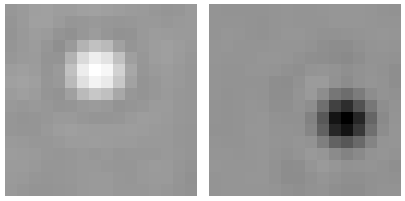

In [39]:
i, j = 157, 25

plot_weights(tr.model.layer.get_weight().T[[i, j]].reshape(-1, 16, 16), nrows=1, dpi=50, method='abs-max');

In [43]:
show_movie(sta[i].reshape(-1, 16, 16))

In [44]:
show_movie(sta[j].reshape(-1, 16, 16))

In [45]:
s_kers = np_nans((len(sta), 16, 16))
t_kers = np_nans((len(sta), n_lags + 1))

for i in range(len(sta)):
    uu, ss, vvh = torch.linalg.svd(sta[i], full_matrices=False)

    s_kers[i] = tonp(vvh[0]).reshape(16, 16)
    t_kers[i] = tonp(uu[:, 0])

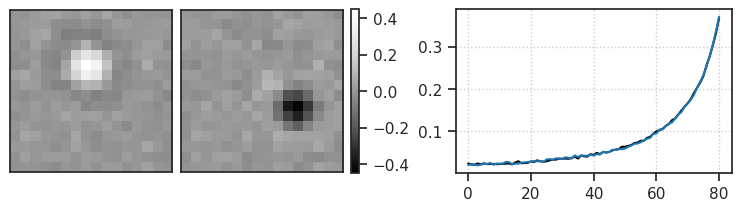

In [52]:
fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

i, j = 157, 25
vminmax = np.abs(s_kers[[i, j]]).max()

im = axes[0].imshow(s_kers[i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[i], color='k')
axes[2].plot(t_kers[j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

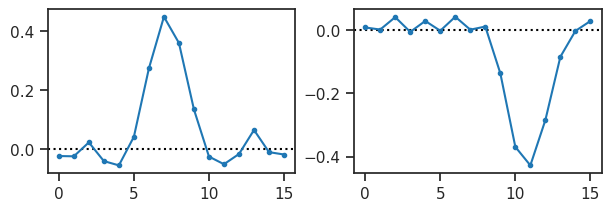

In [62]:
fig, axes = create_figure(1, 2)
axes[0].plot(s_kers[i][5], marker='.')
axes[1].plot(s_kers[j][9], marker='.')
for ax in axes.flat:
    ax.axhline(0, color='k', ls=':', zorder=0)
plt.show()

In [64]:
w = tr.model.layer.get_weight()
w = tonp(w).T.reshape(-1, 16, 16)
w.shape

(256, 16, 16)

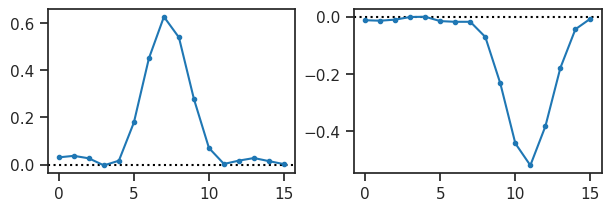

In [66]:
fig, axes = create_figure(1, 2)
axes[0].plot(w[i][5], marker='.')
axes[1].plot(w[j][9], marker='.')
for ax in axes.flat:
    ax.axhline(0, color='k', ls=':', zorder=0)
plt.show()

In [68]:
stim = tonp(output['x'].flatten(end_dim=1))
spks = tonp(output['samples'].flatten(end_dim=1))

stim.shape, spks.shape

((550000, 256), (550000, 256))

In [69]:
from sklearn.linear_model import PoissonRegressor

In [87]:
glm = PoissonRegressor(
    alpha=1.0,
    max_iter=200,
    tol=1e-5,
).fit(stim, spks[:, i])

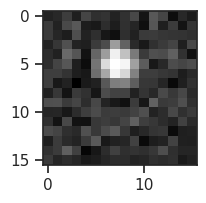

In [88]:
imshow(glm.coef_.reshape(16, 16), cmap='Greys_r')
plt.show()

In [89]:
glm = PoissonRegressor(
    alpha=1.0,
    max_iter=200,
    tol=1e-5,
).fit(stim, spks[:, j])

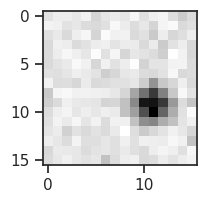

In [90]:
imshow(glm.coef_.reshape(16, 16), cmap='Greys_r')
plt.show()

In [124]:
# get w
u0 = tonp(tr.model.layer.u_init[0].squeeze())
w = tr.model.layer.get_weight()
w = tonp(w.T)[np.argsort(u0)]

# get max pix
max_pix = np.argmax(np.abs(w), axis=-1)
max_pix = np.unravel_index(max_pix, (16, 16))
max_pix = np.stack(max_pix, axis=1)

absmax = np.max(np.abs(w)).item()
w_rescaled = 0.5 * (w / absmax + 1)

w, w_rescaled = map(
    lambda t: tonp(t).reshape(-1, 16, 16),
    [w, w_rescaled],
)

In [125]:
max_pix.shape

(256, 2)

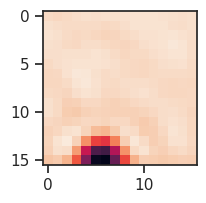

In [128]:
imshow(w[-1])

In [129]:
max_pix[-1]

array([15,  6])

## Plot, save as PDF

In [217]:
nrows = 3
ncols = 8
fig_list = []

for i_outer in tqdm(range(int(np.ceil(len(w) / ncols)))):

    fig, axes = create_figure(
        nrows,
        ncols,
        (2.4 * ncols, 2.0 * nrows),
        sharey='row',
        sharex='all',
        height_ratios=[1.5, 1, 1],
    )

    for i_inner in range(ncols):
        i_global = i_outer * ncols + i_inner
        # plot
        i, j = max_pix[i_global]
        axes[1, i_inner].plot(w[i_global, i, :], color='b', marker='.')
        axes[2, i_inner].plot(w[i_global, :, j], color='g', marker='.')
        # imshow
        axes[0, i_inner].imshow(w[i_global], vmin=-0.8, vmax=0.8, cmap='Greys_r')
        axes[0, i_inner].plot(np.arange(16 + 1) - 0.5, [i] * 17, ls='--', color='b', alpha=0.5)
        axes[0, i_inner].plot([j] * 17, np.arange(16 + 1) - 0.5, ls='--', color='g', alpha=0.6)
    
    remove_ticks(axes[0], False)
    add_grid(axes[1:])
    plt.close()

    fig_list.append(fig)

100%|███████████████████████████████████████████| 32/32 [00:08<00:00,  3.74it/s]


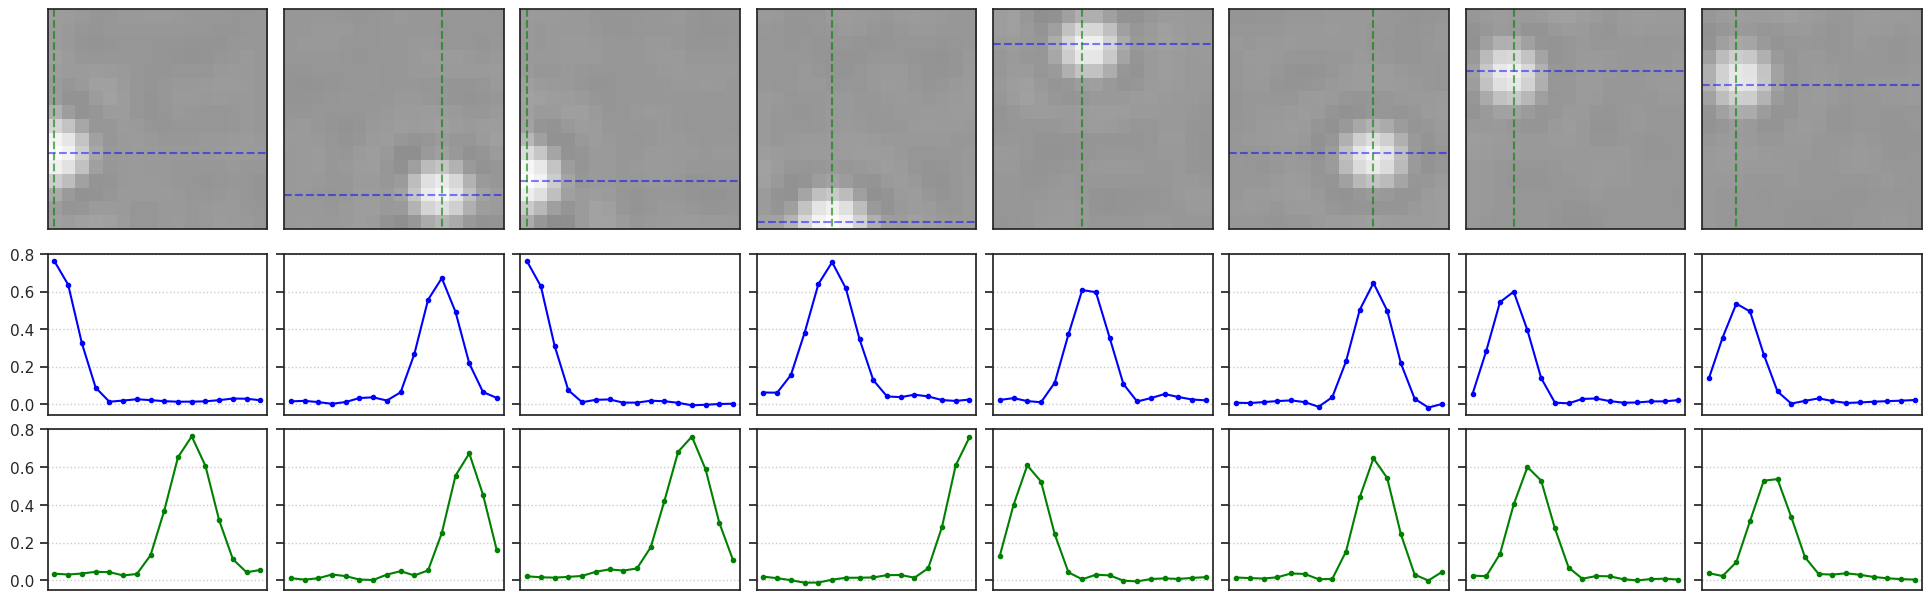

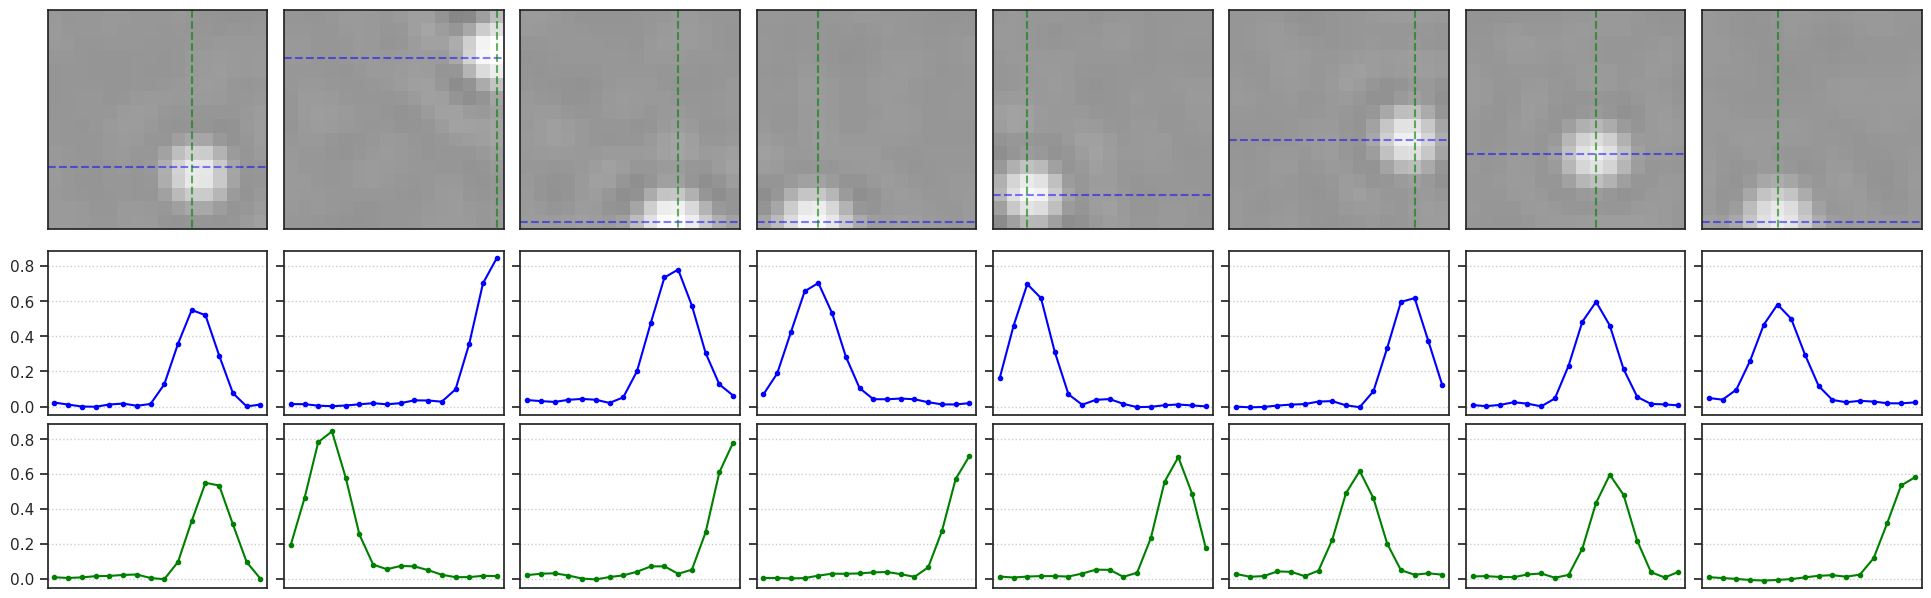

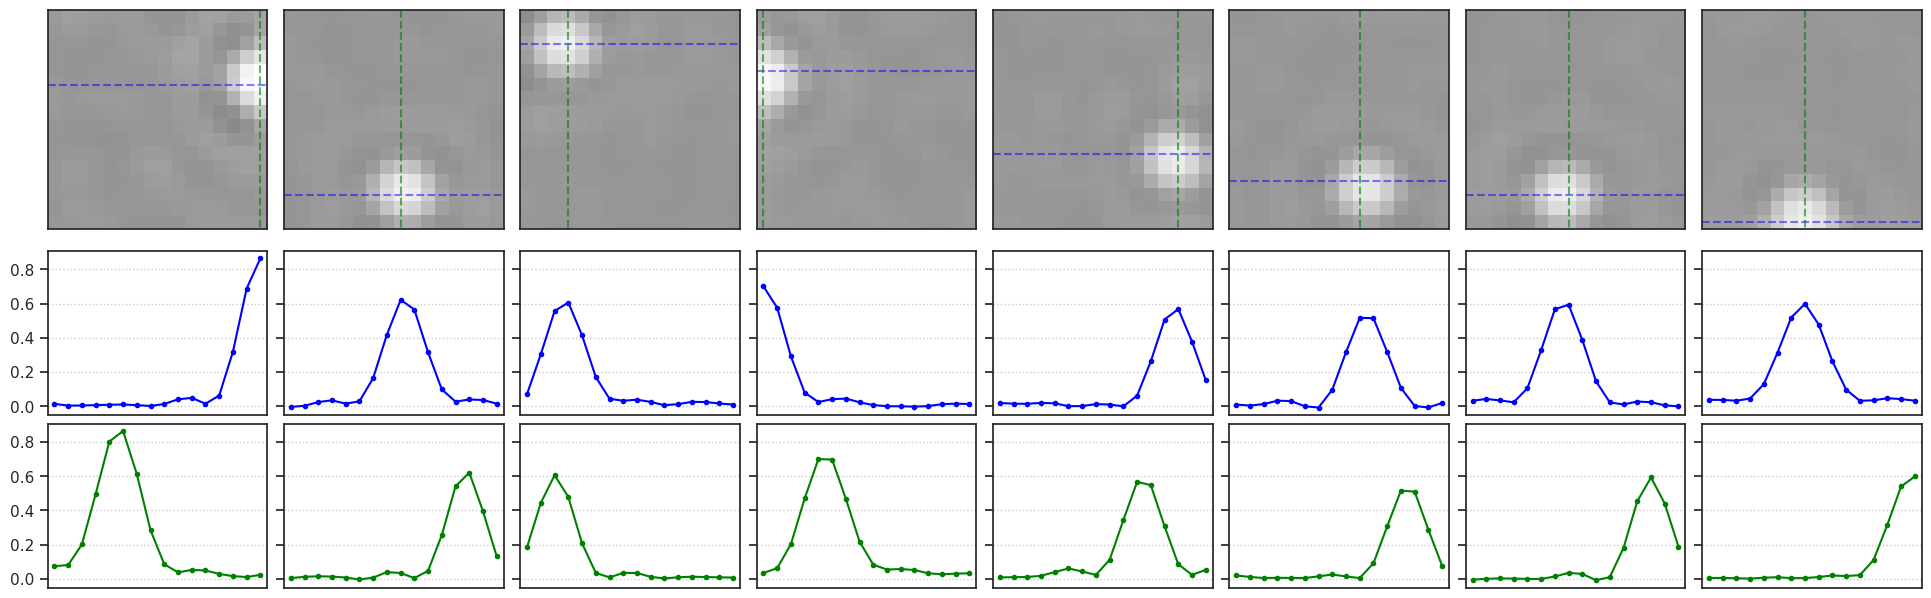

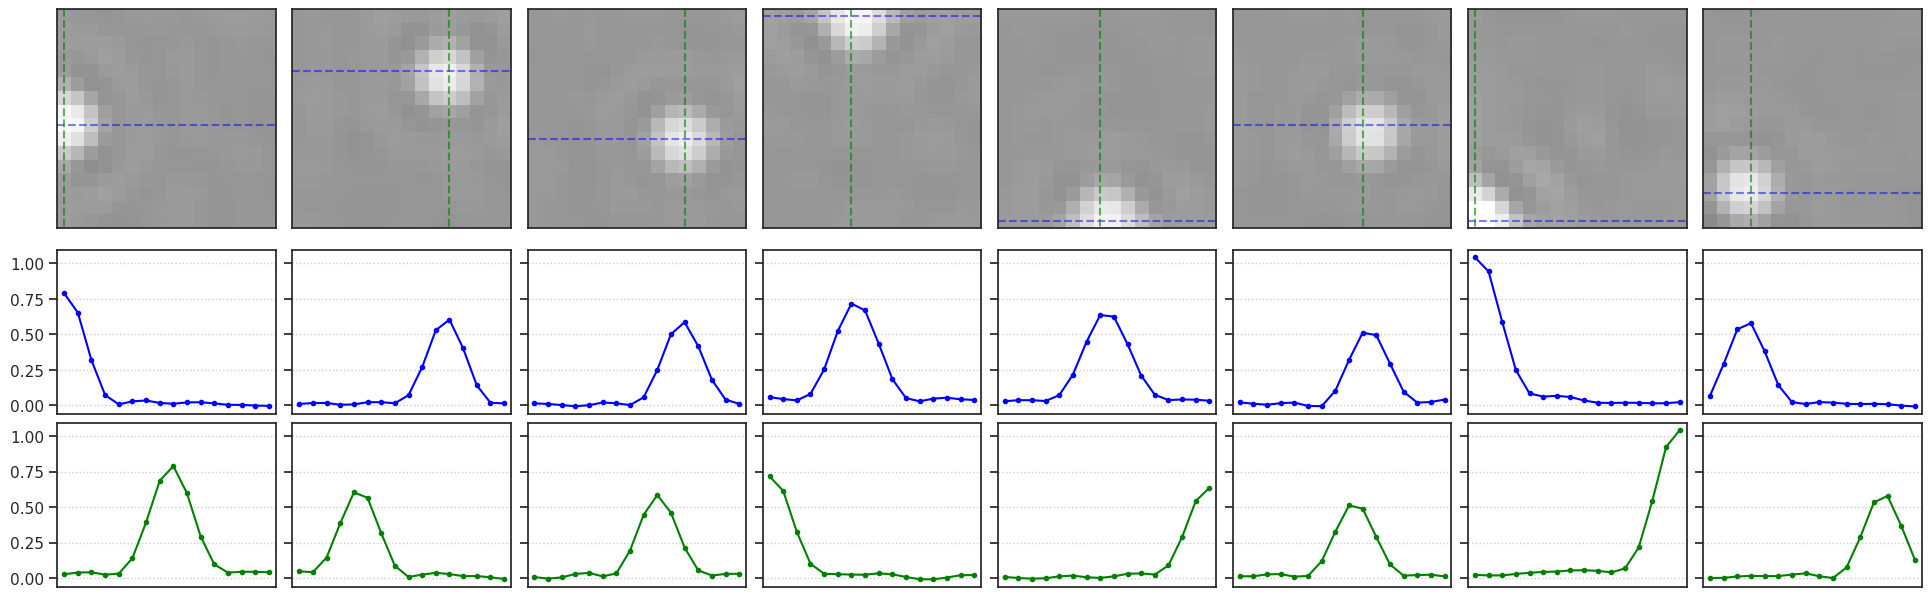

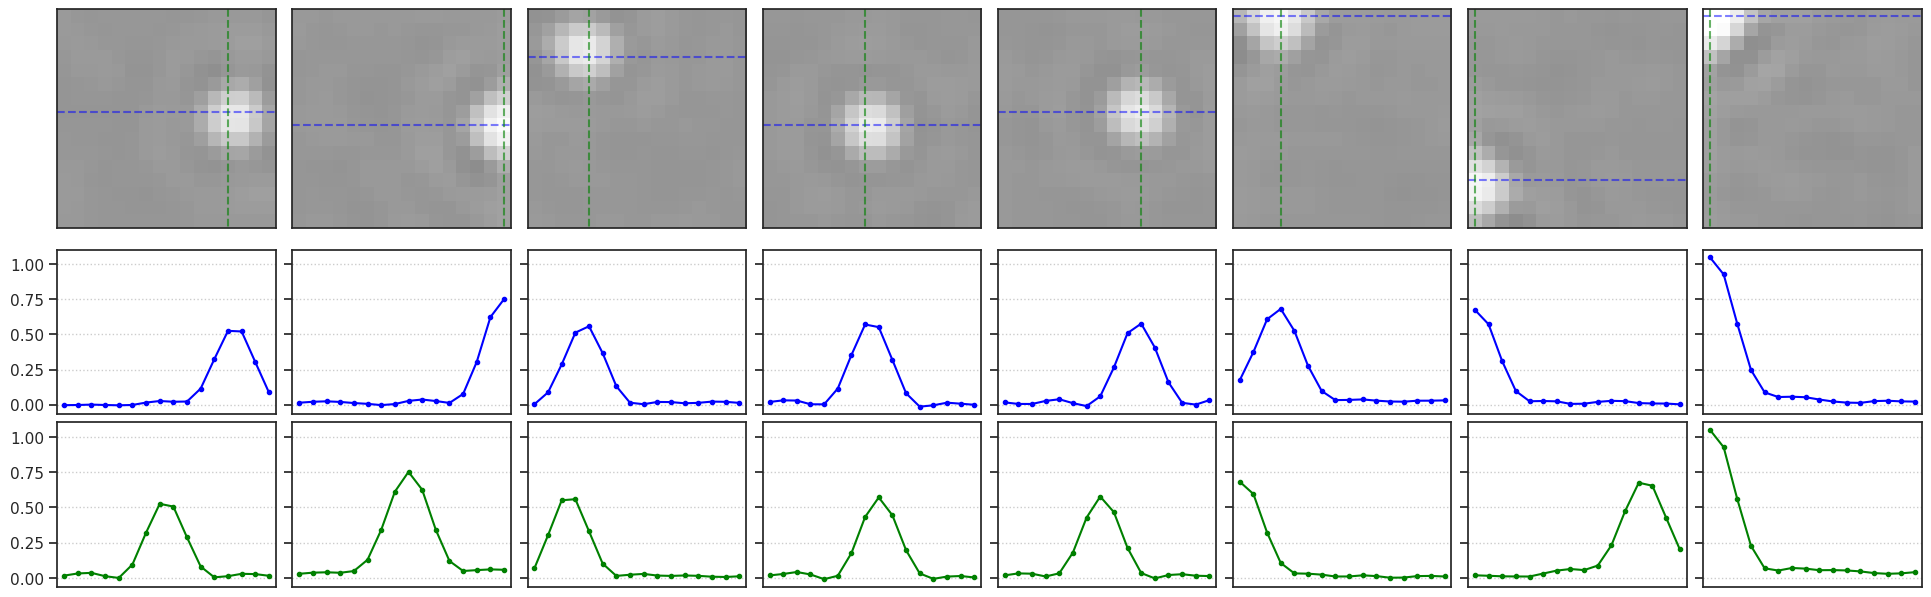

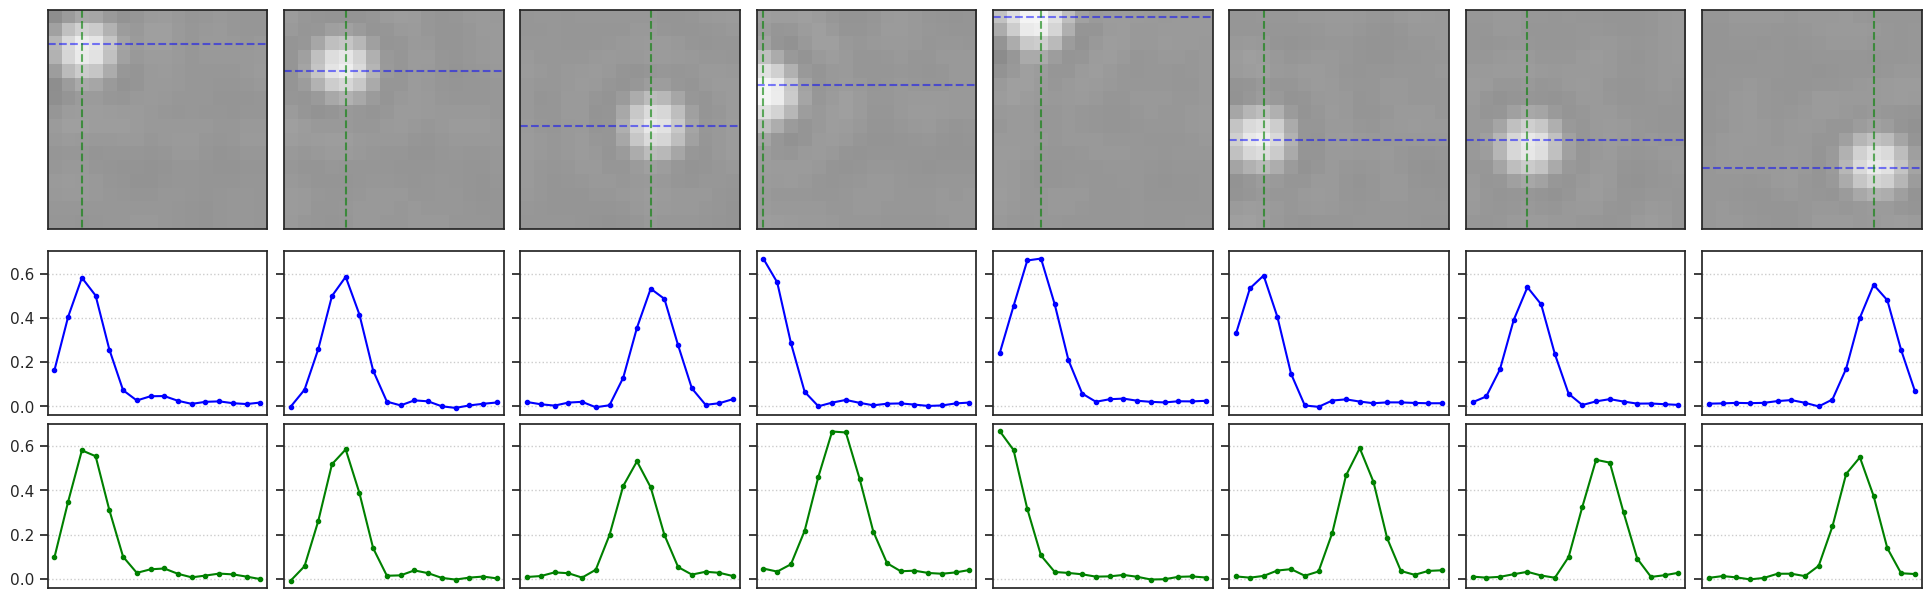

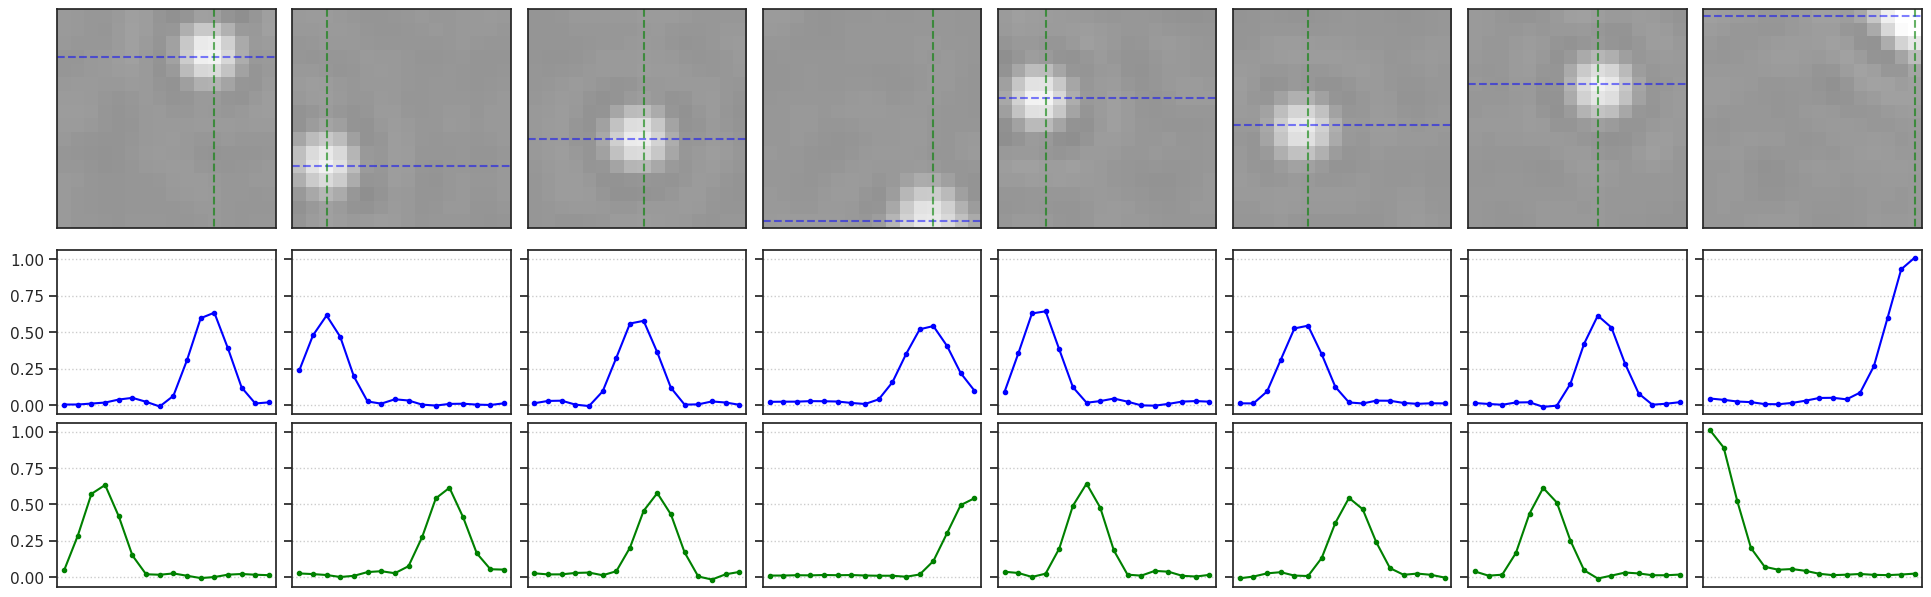

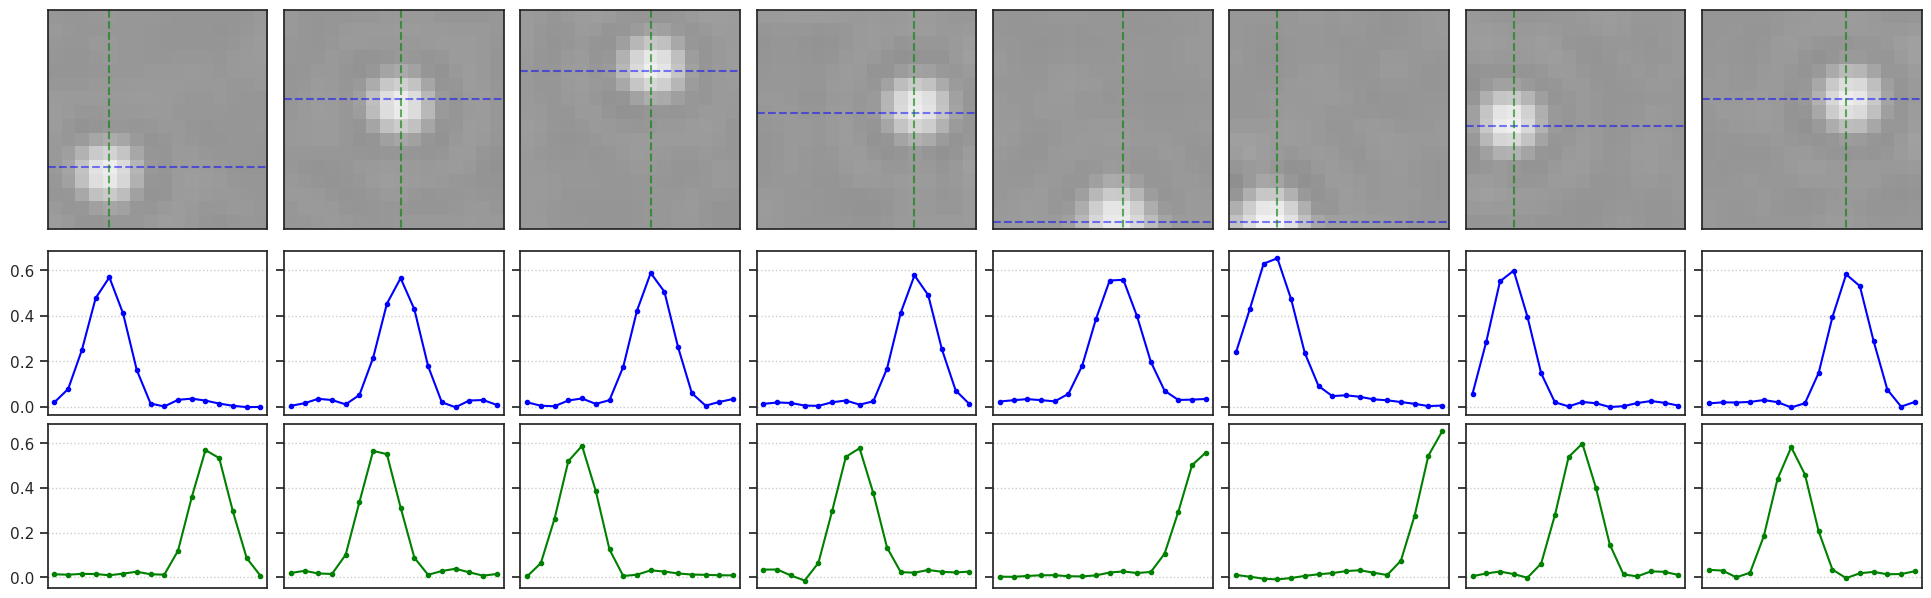

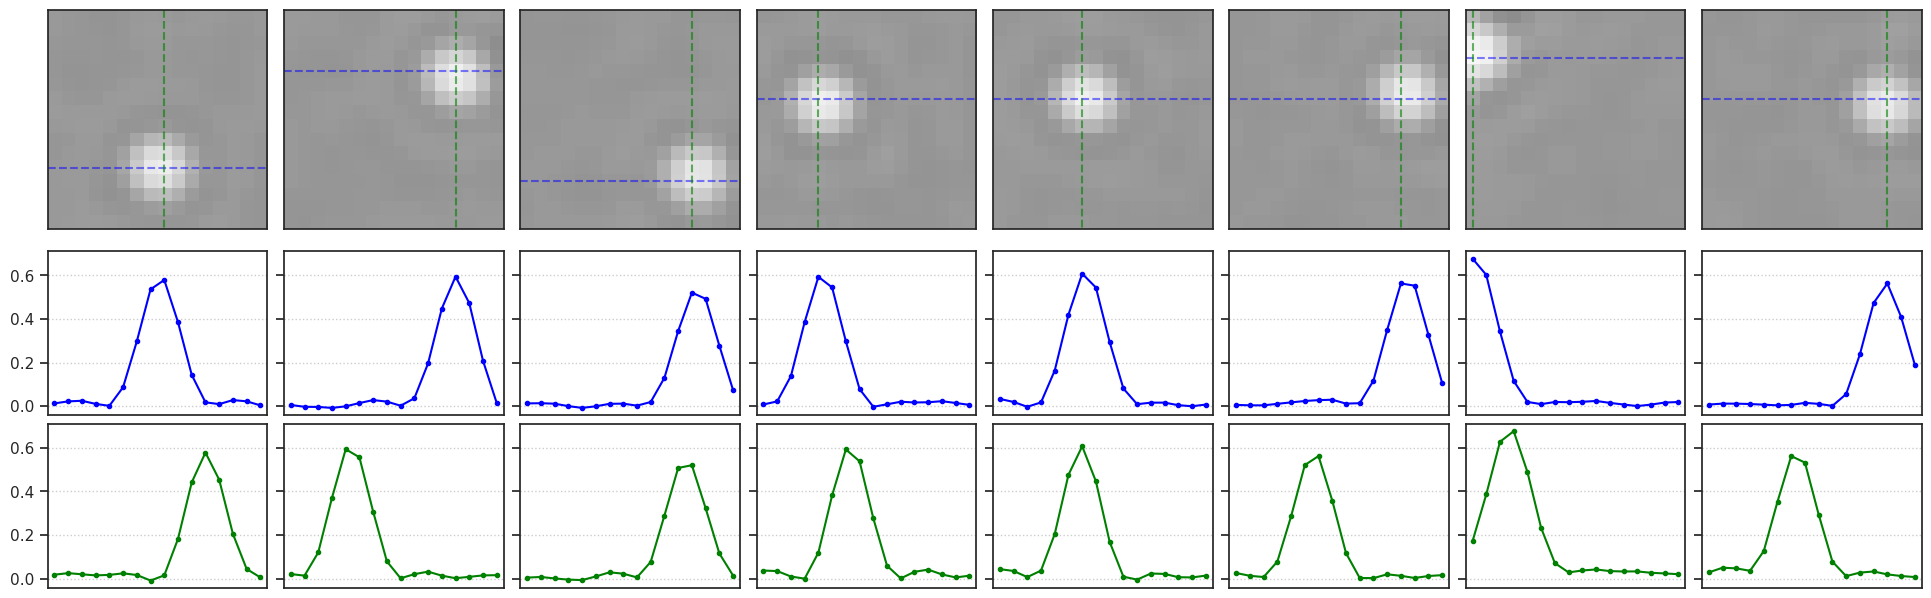

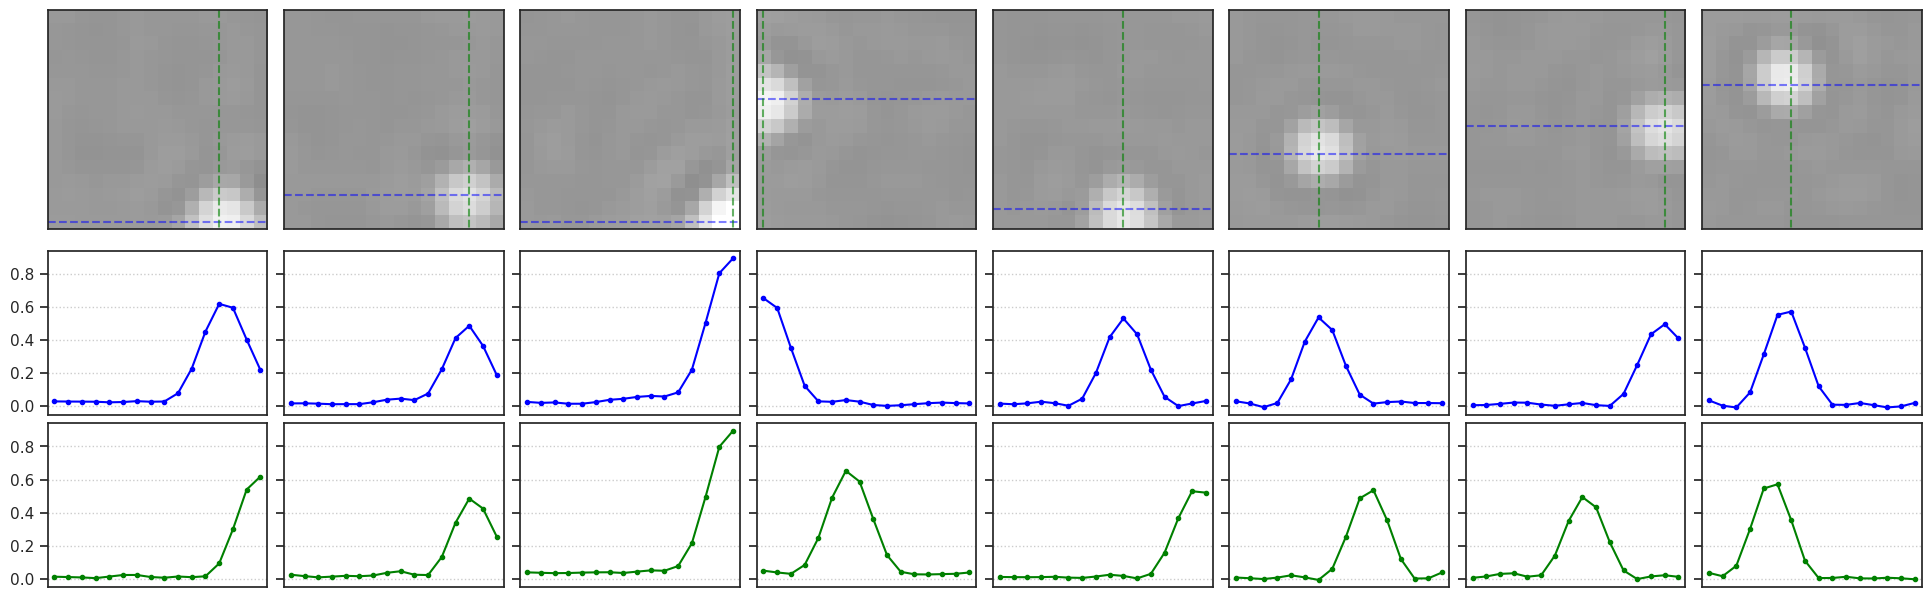

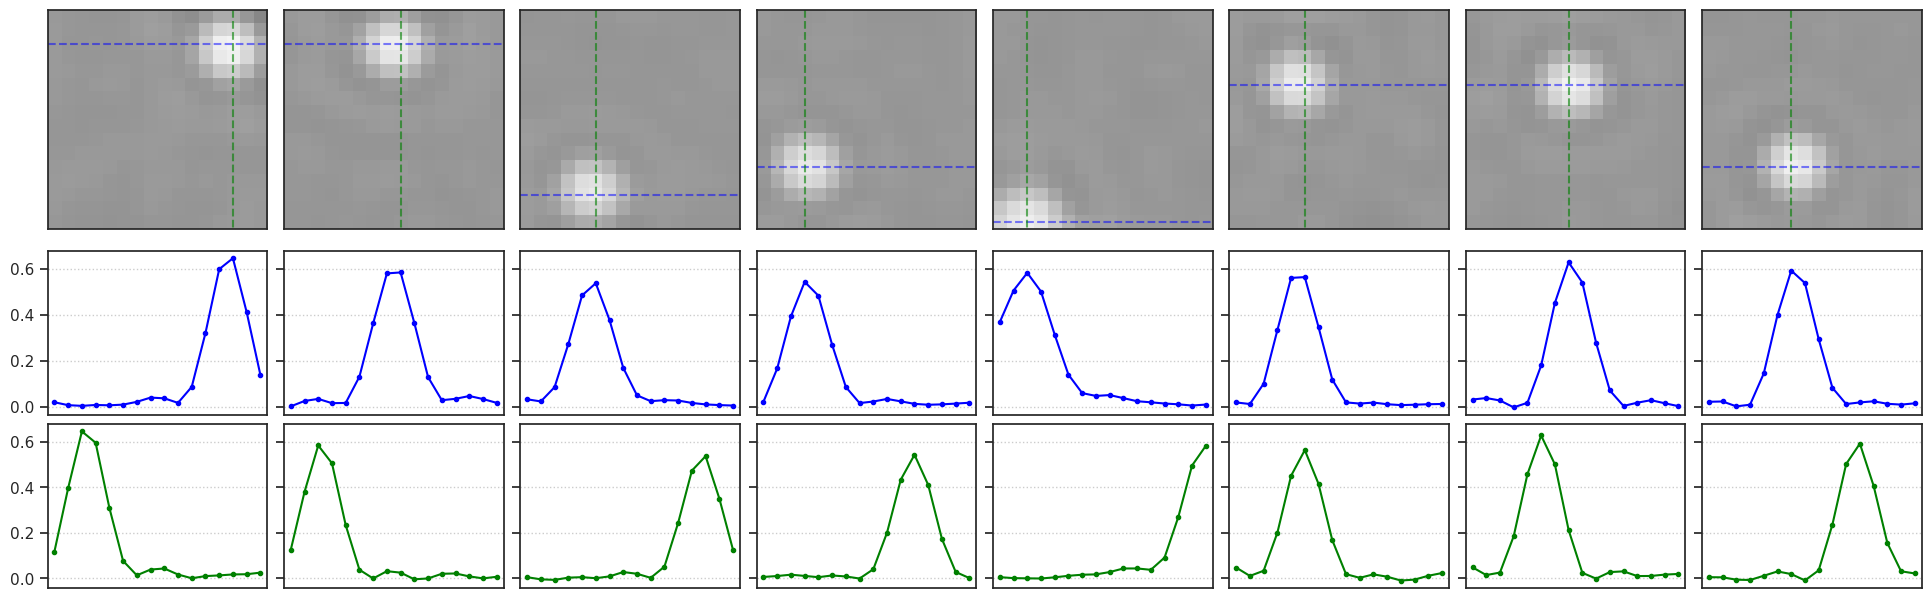

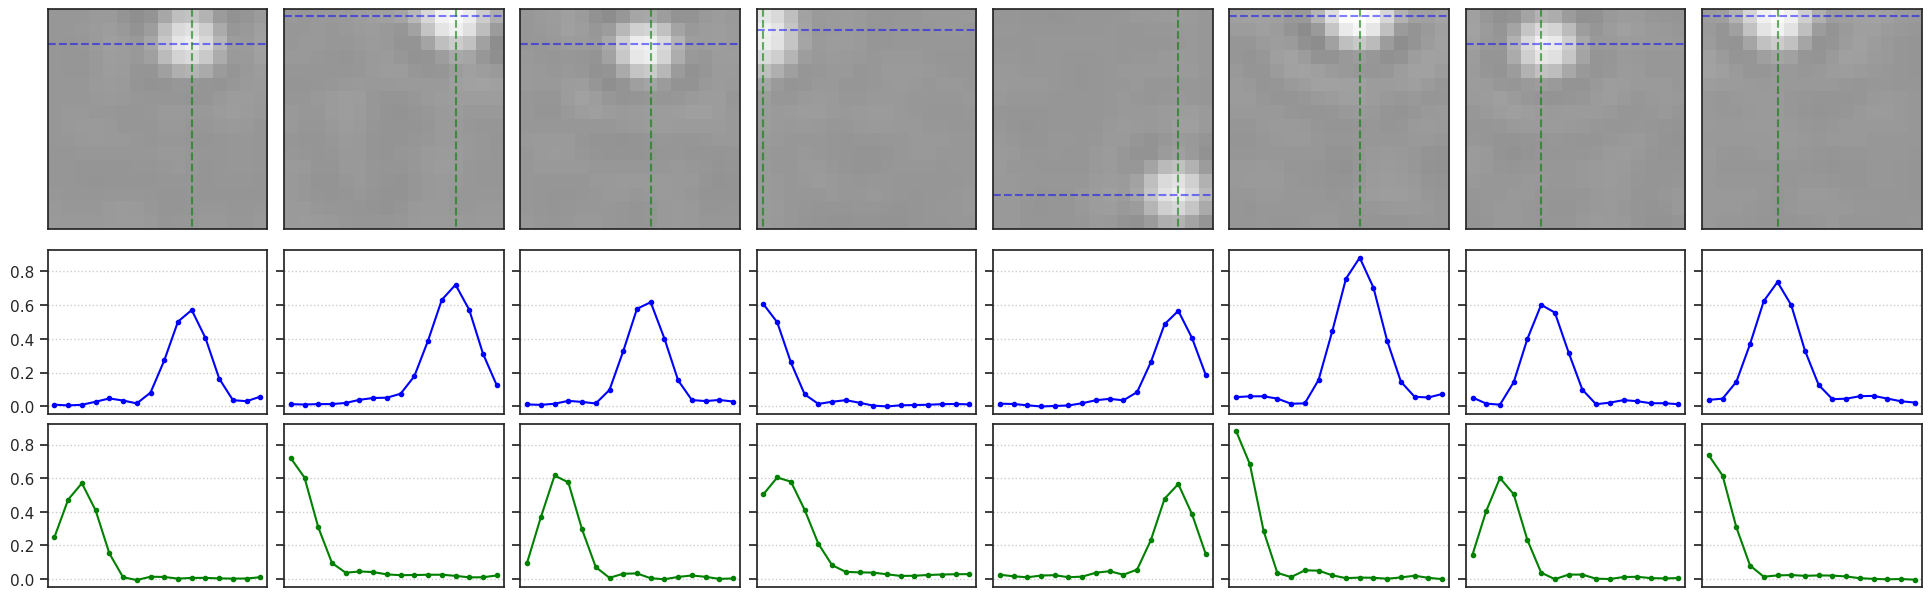

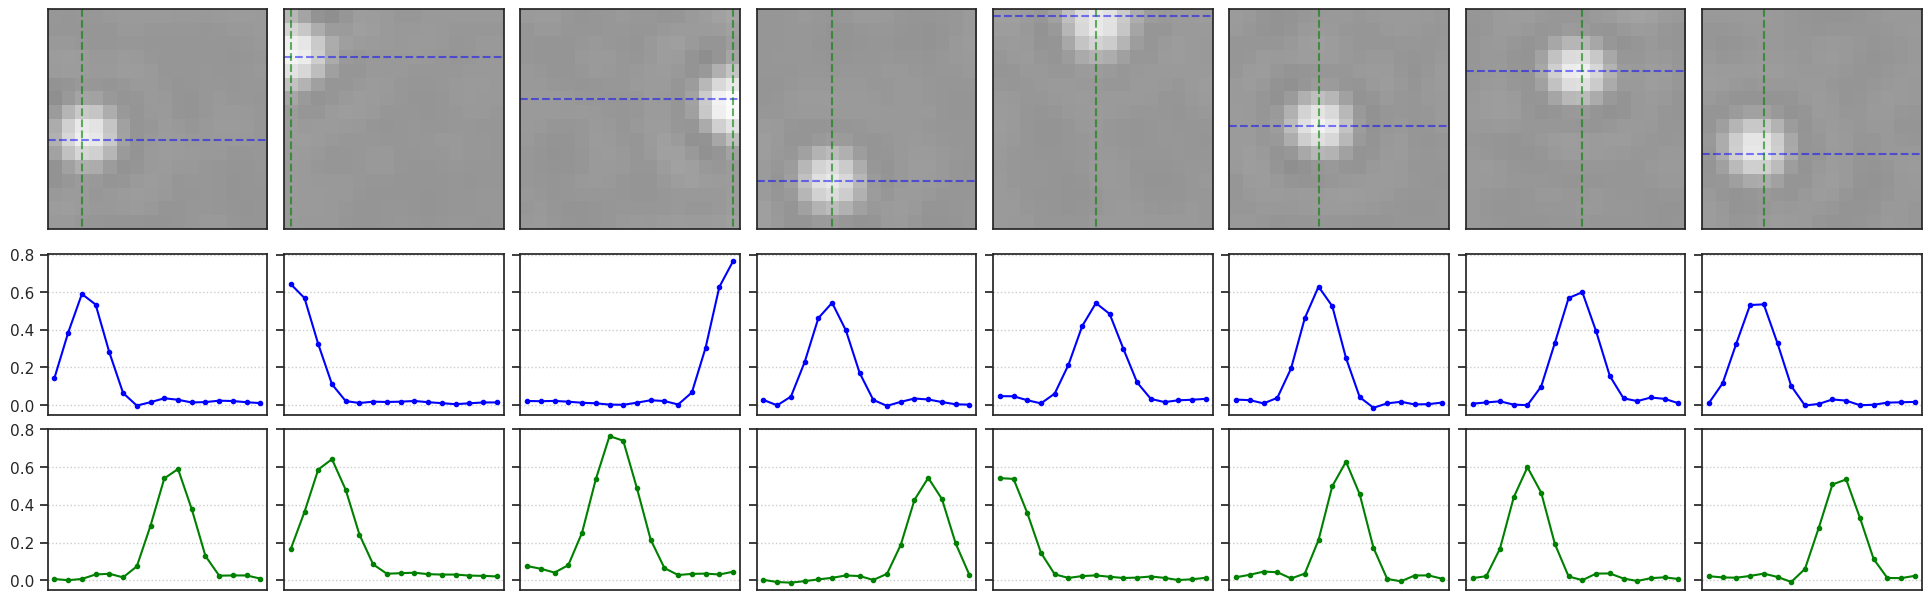

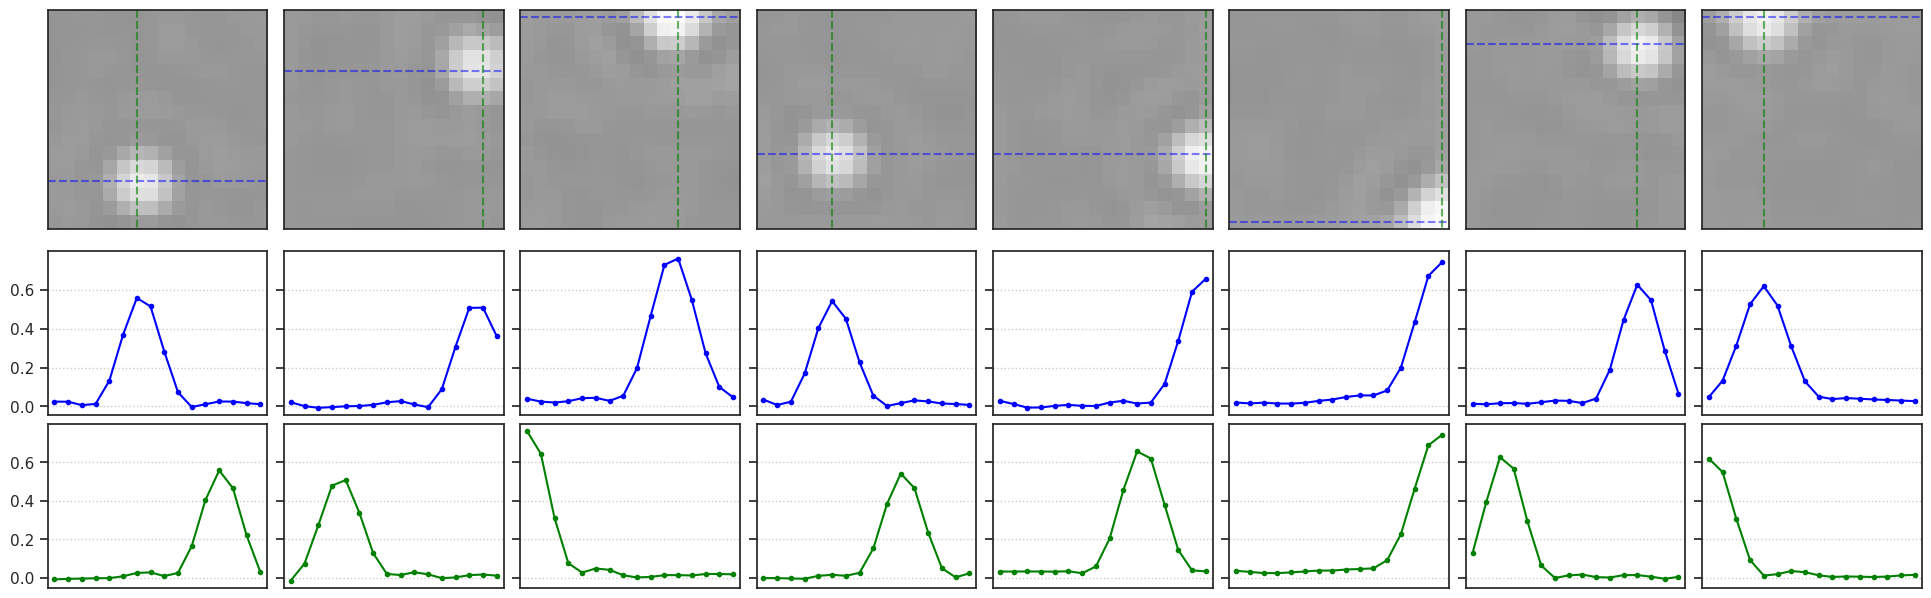

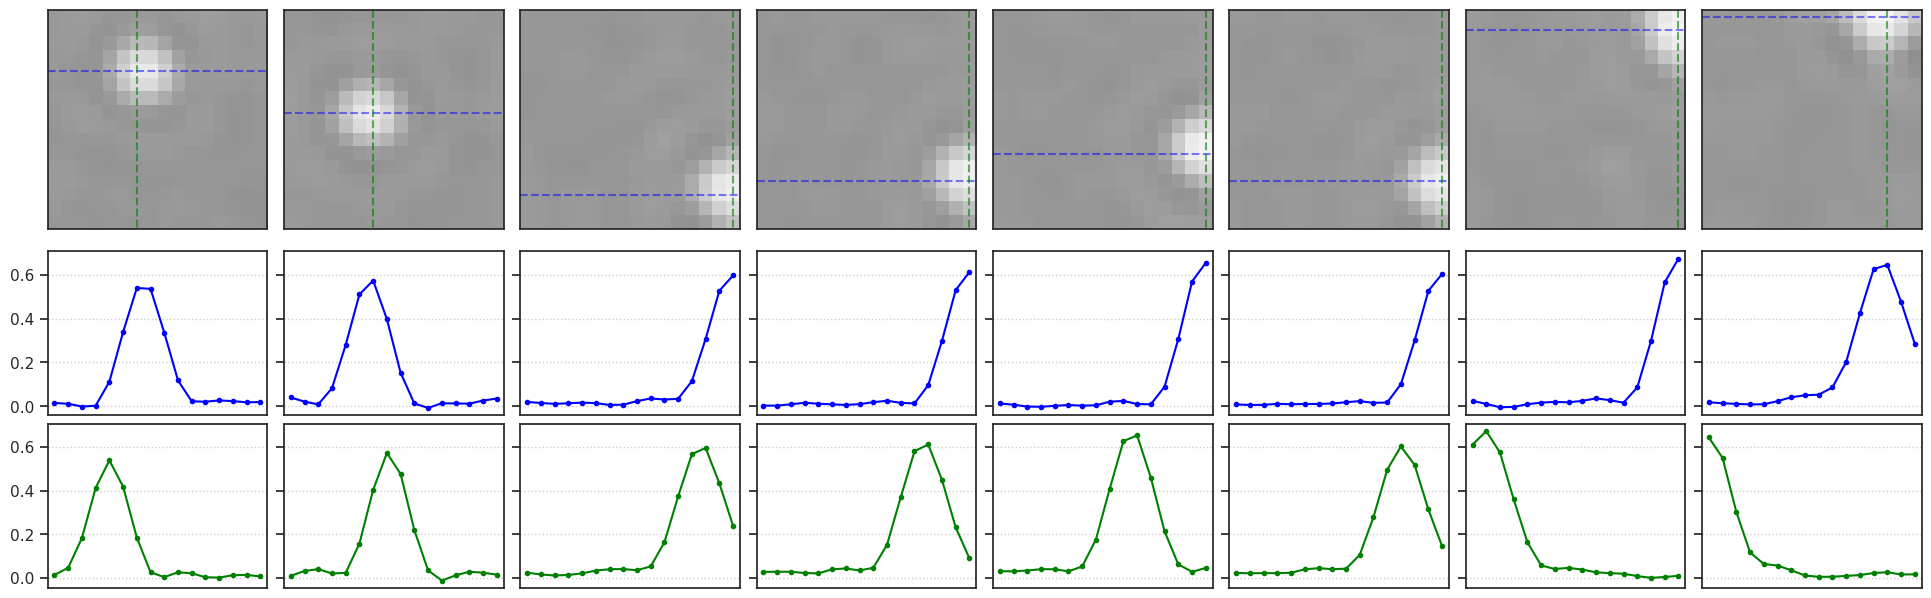

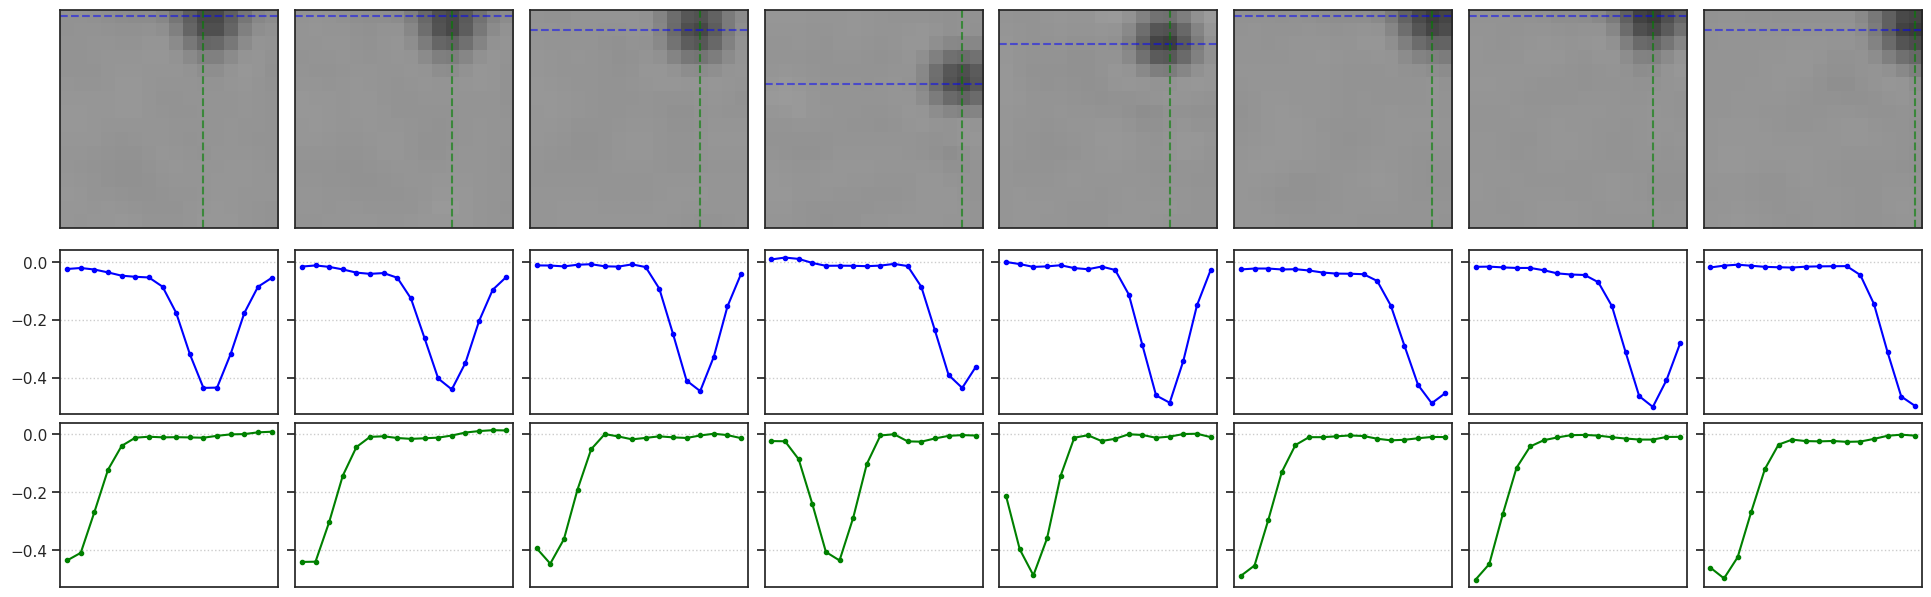

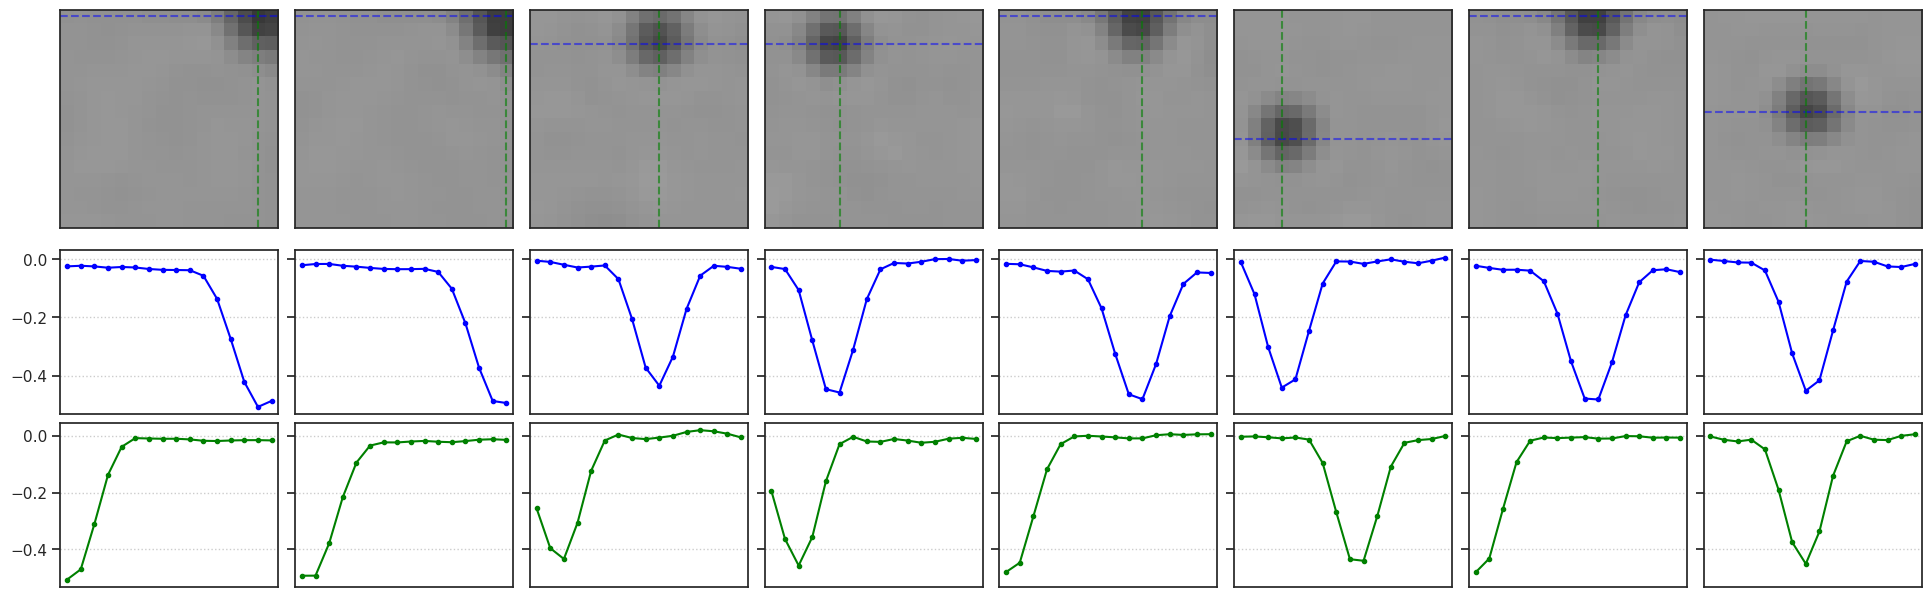

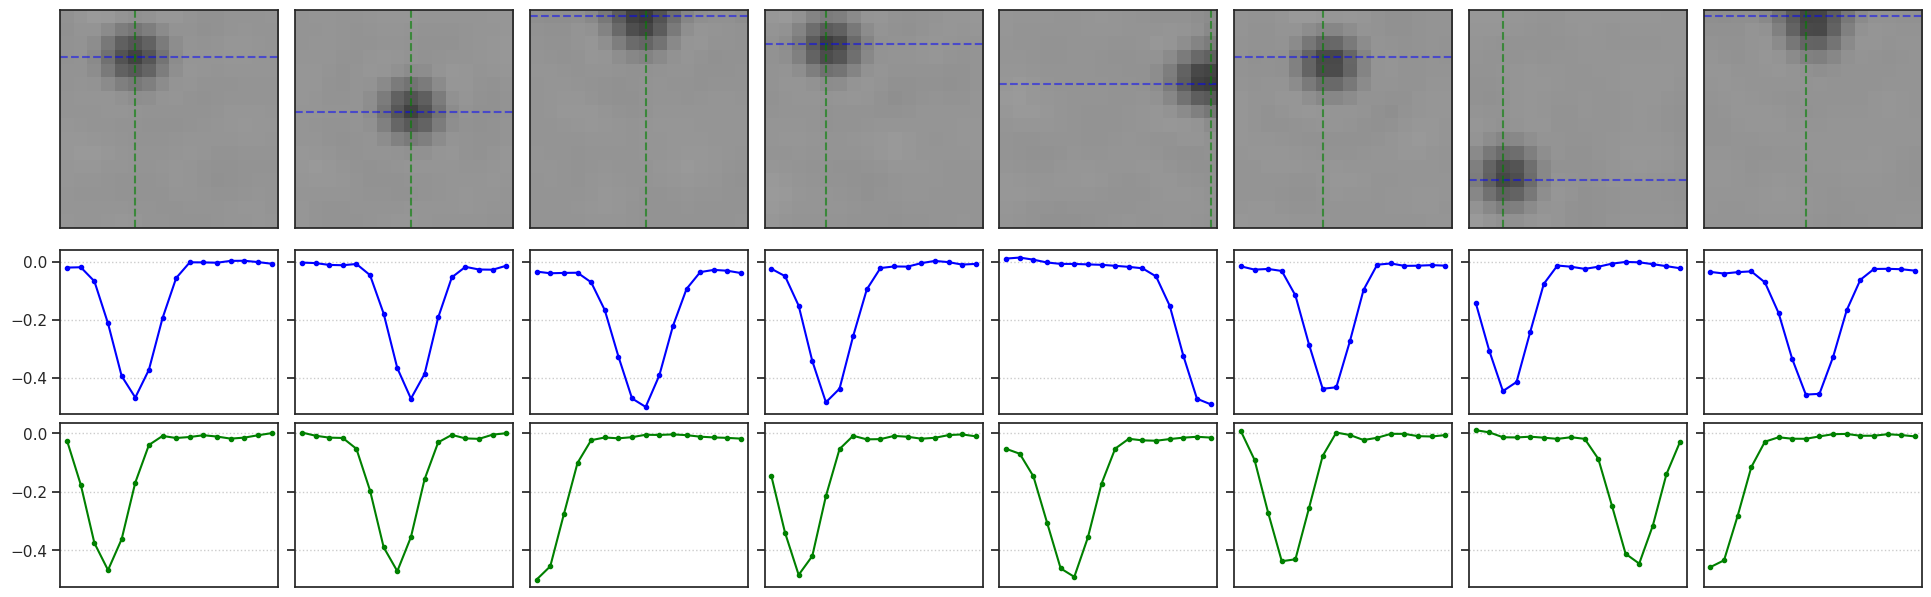

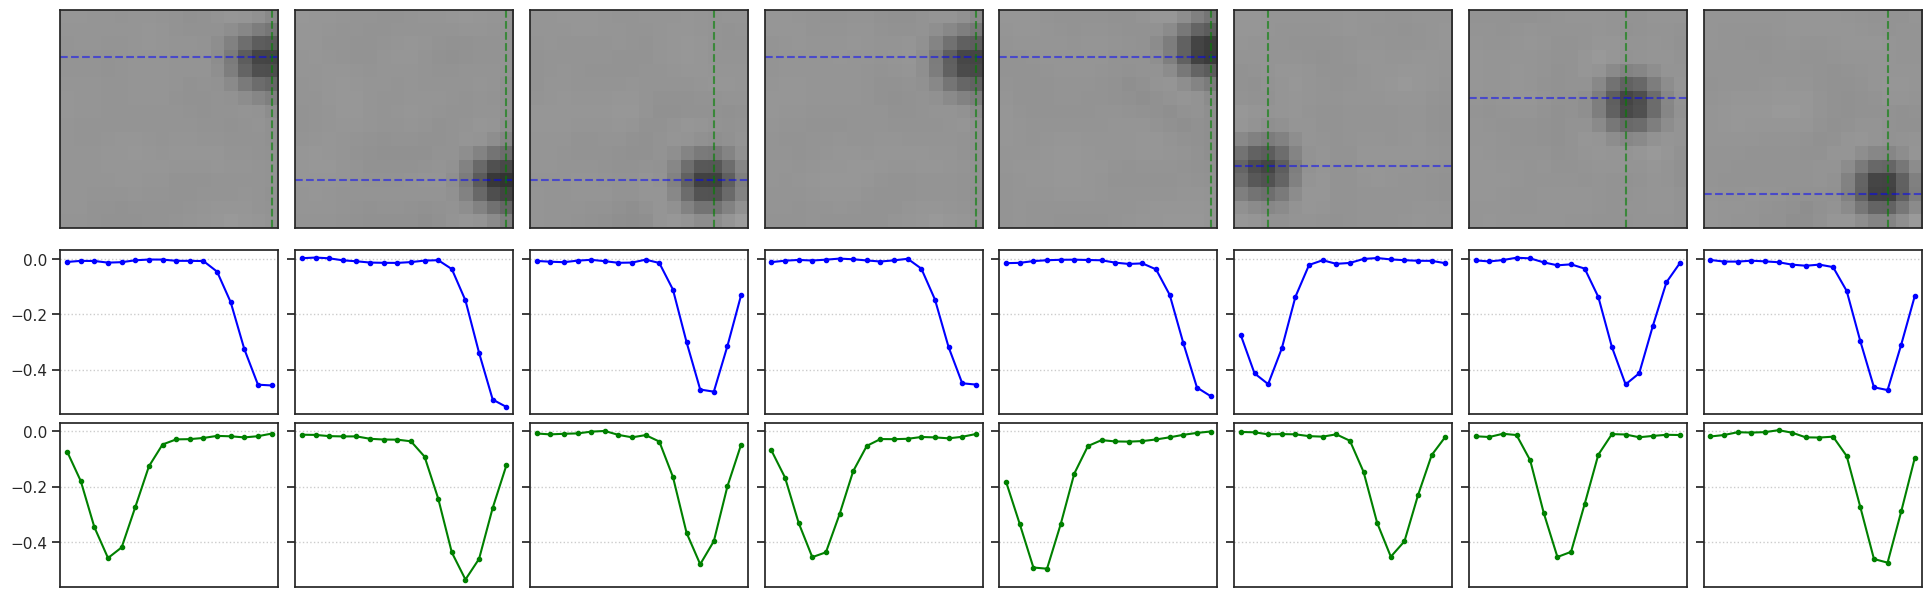

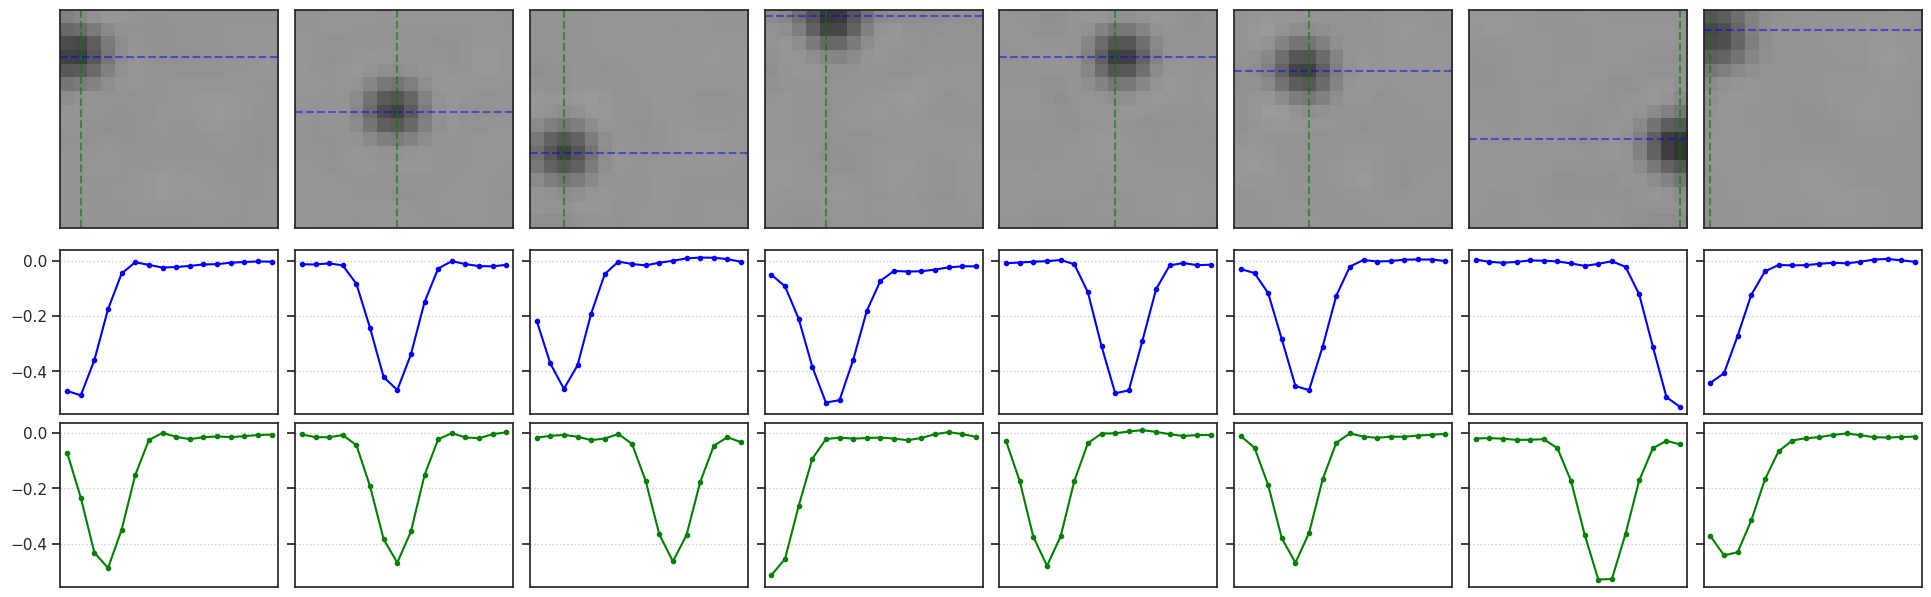

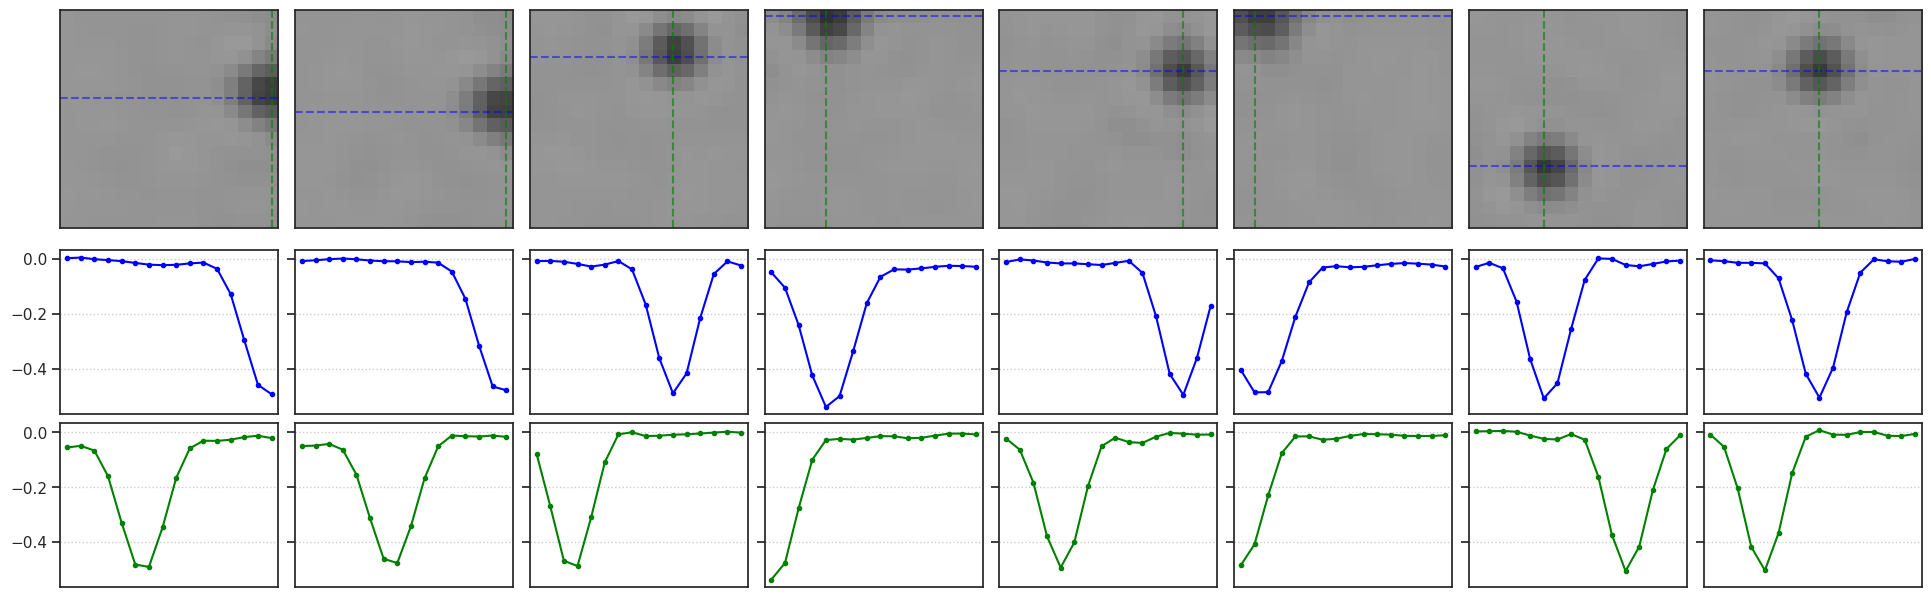

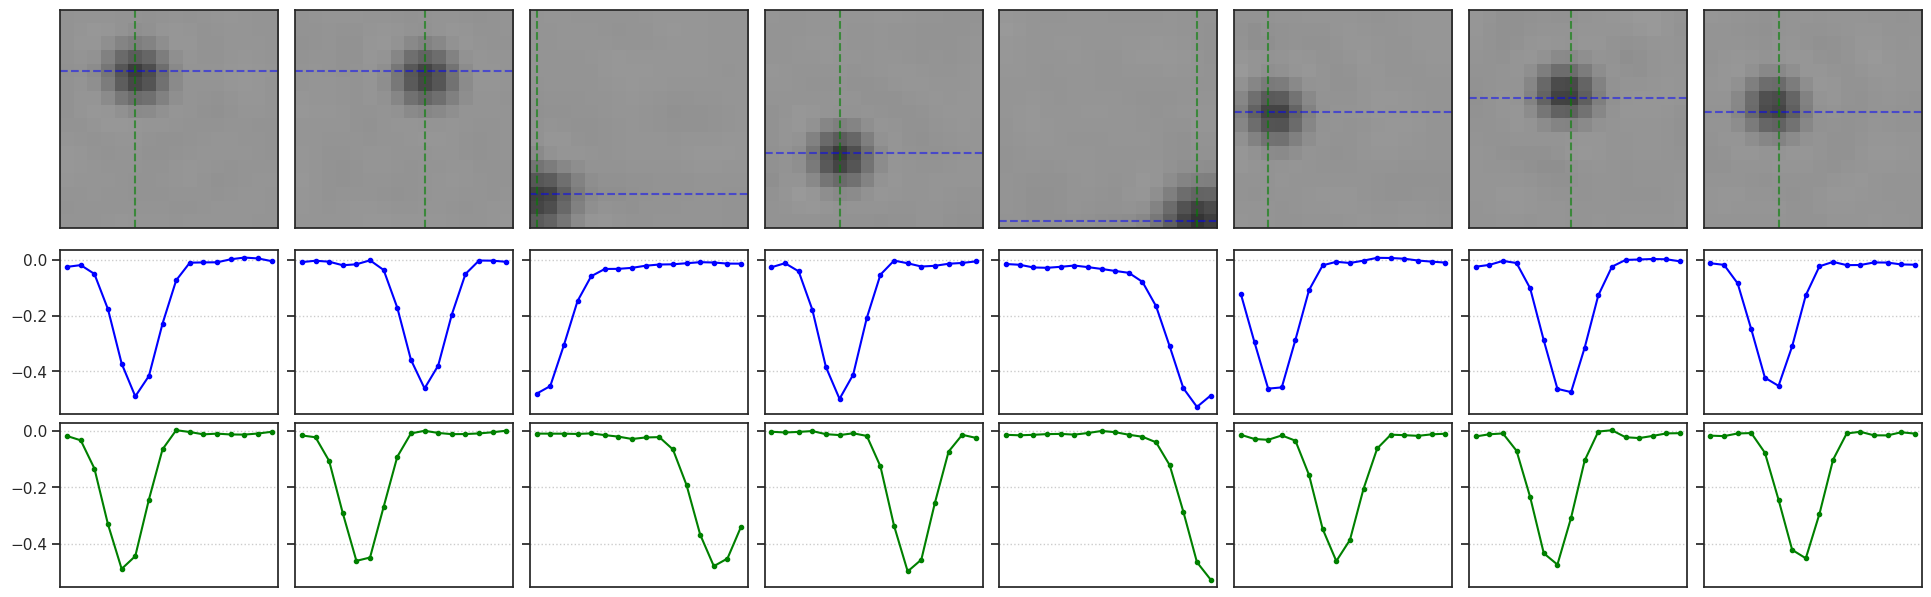

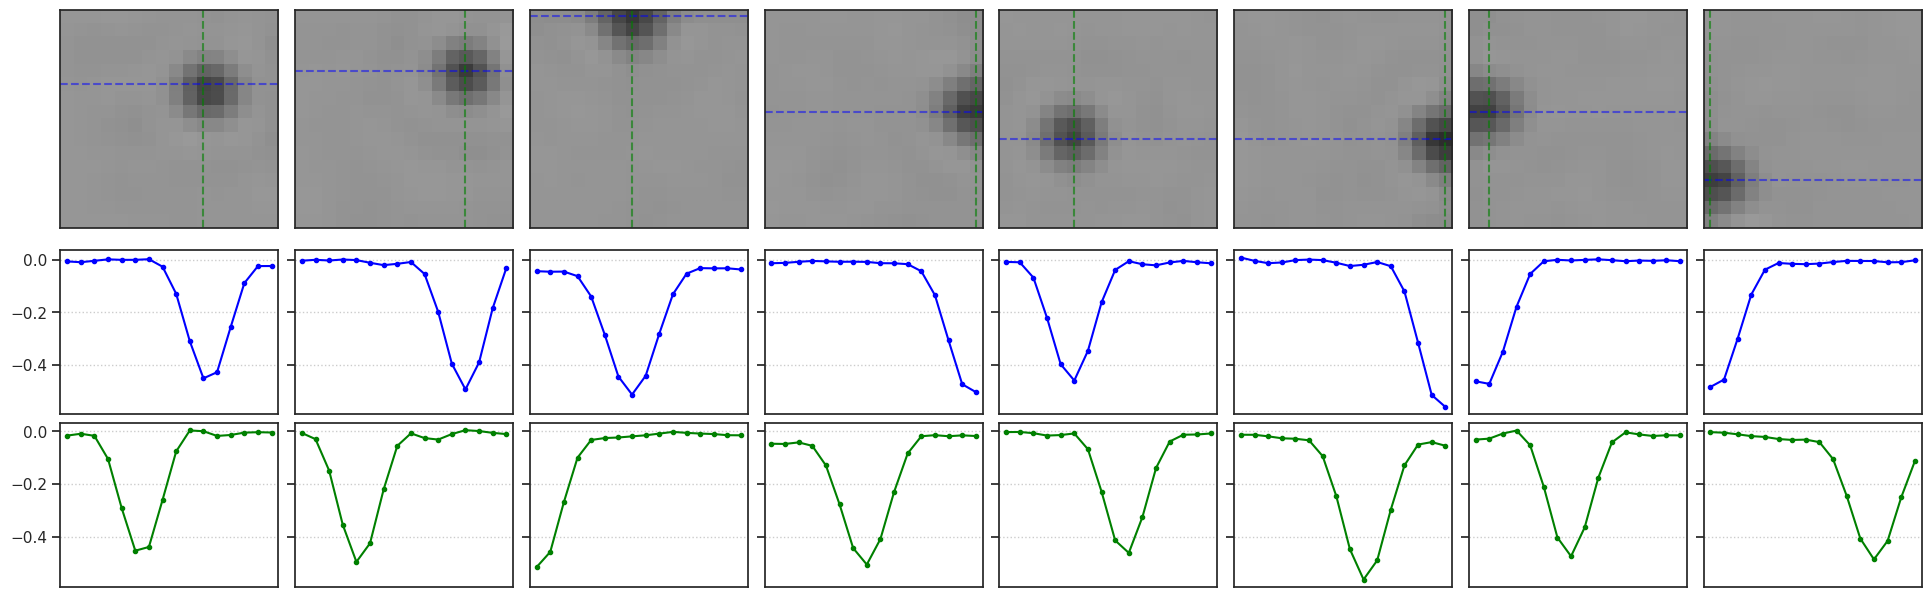

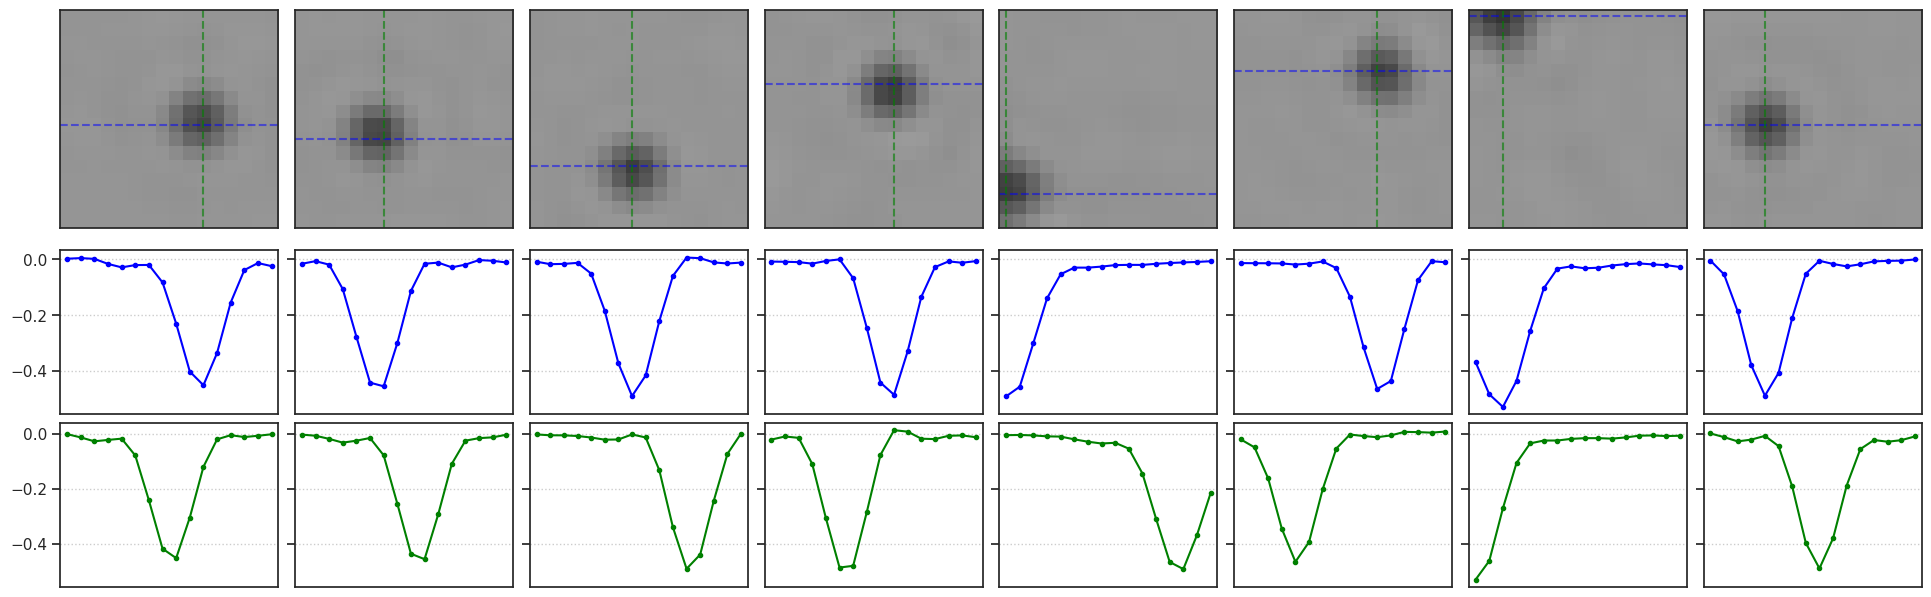

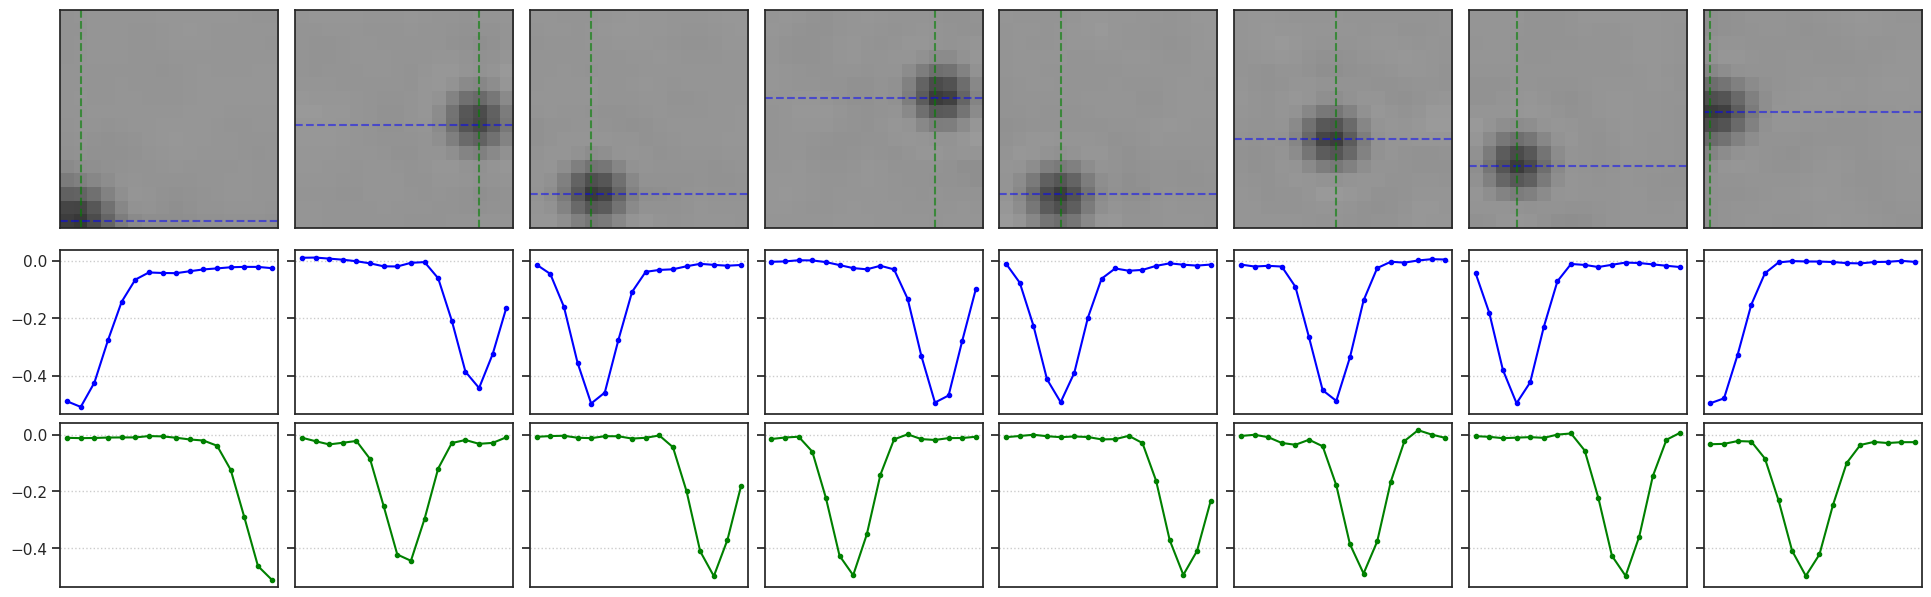

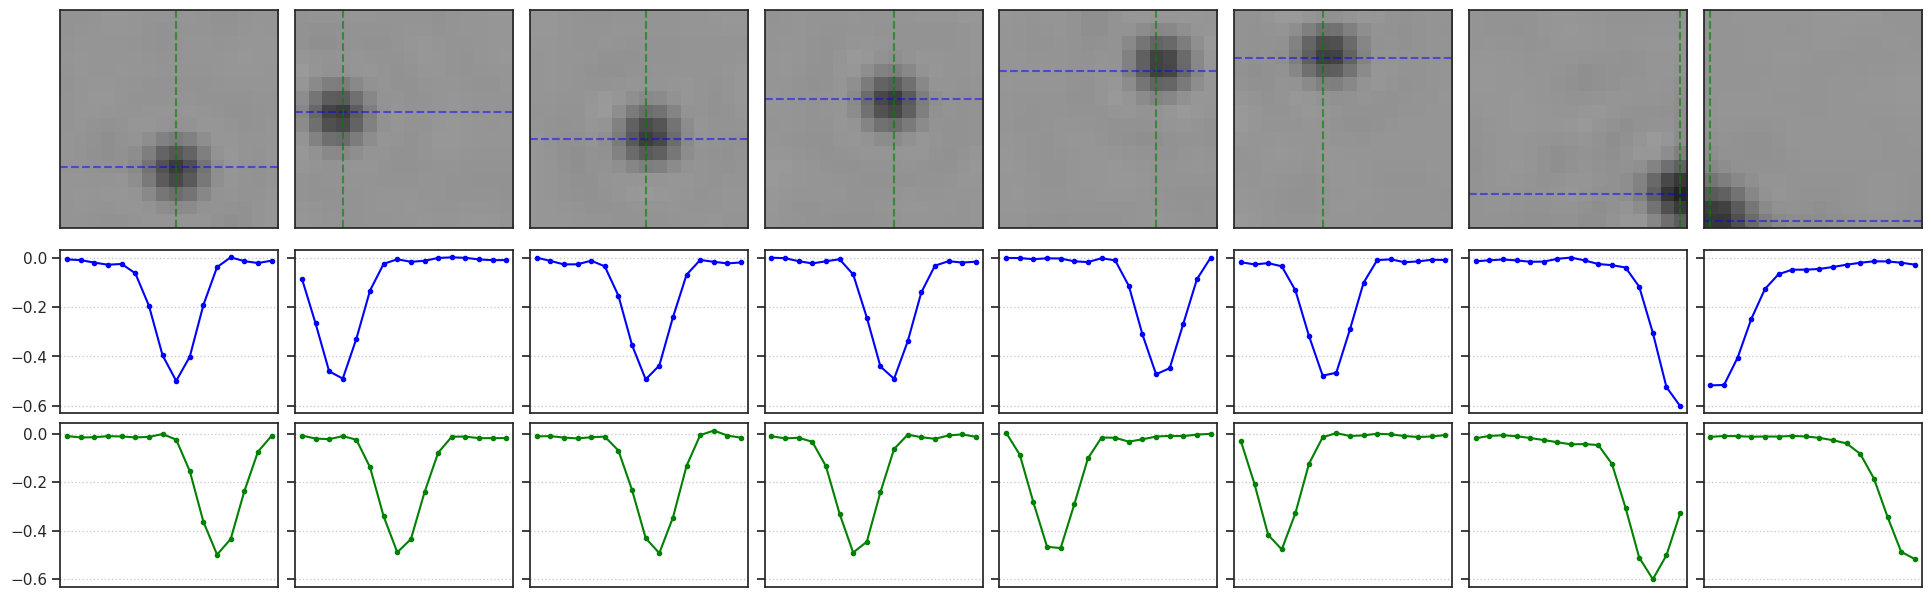

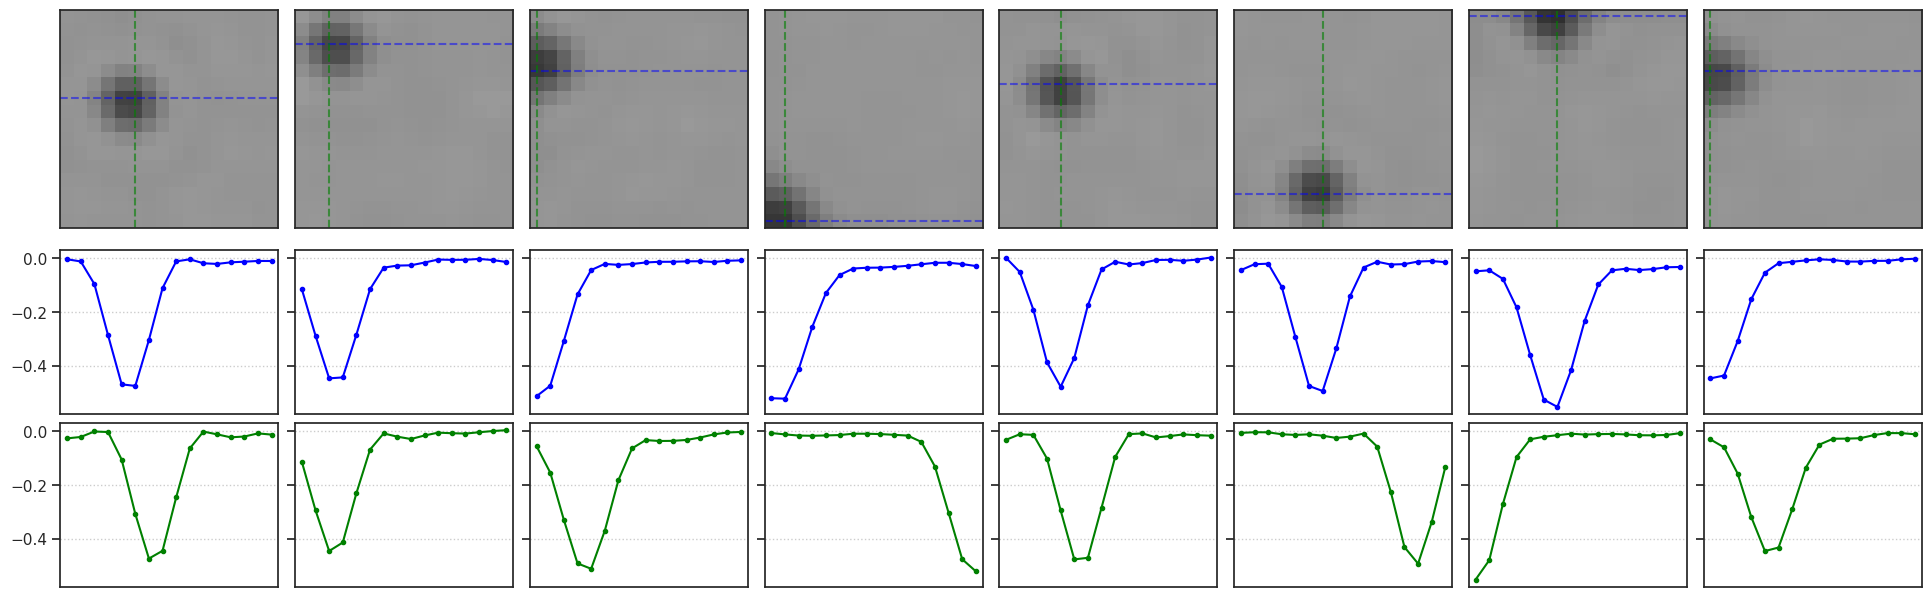

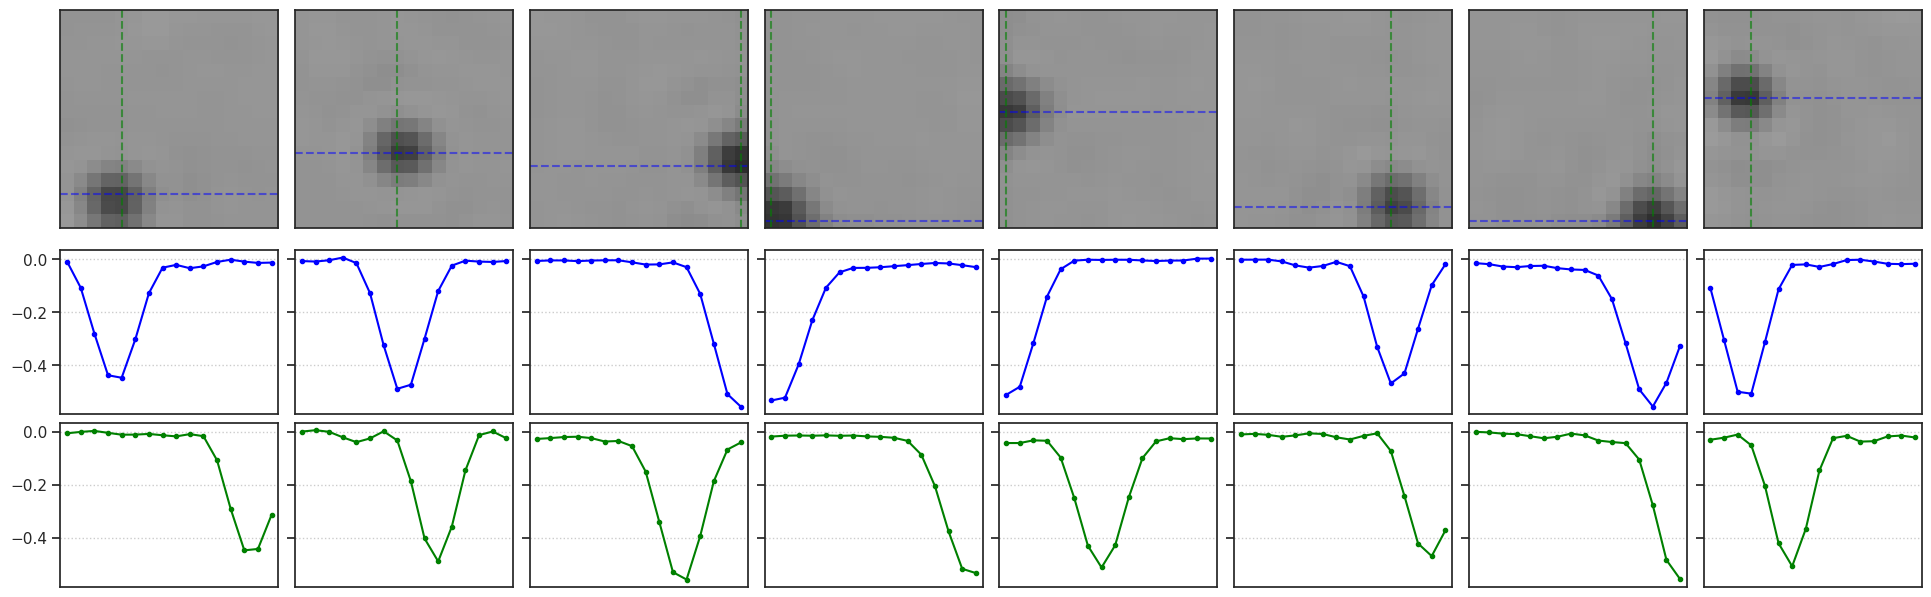

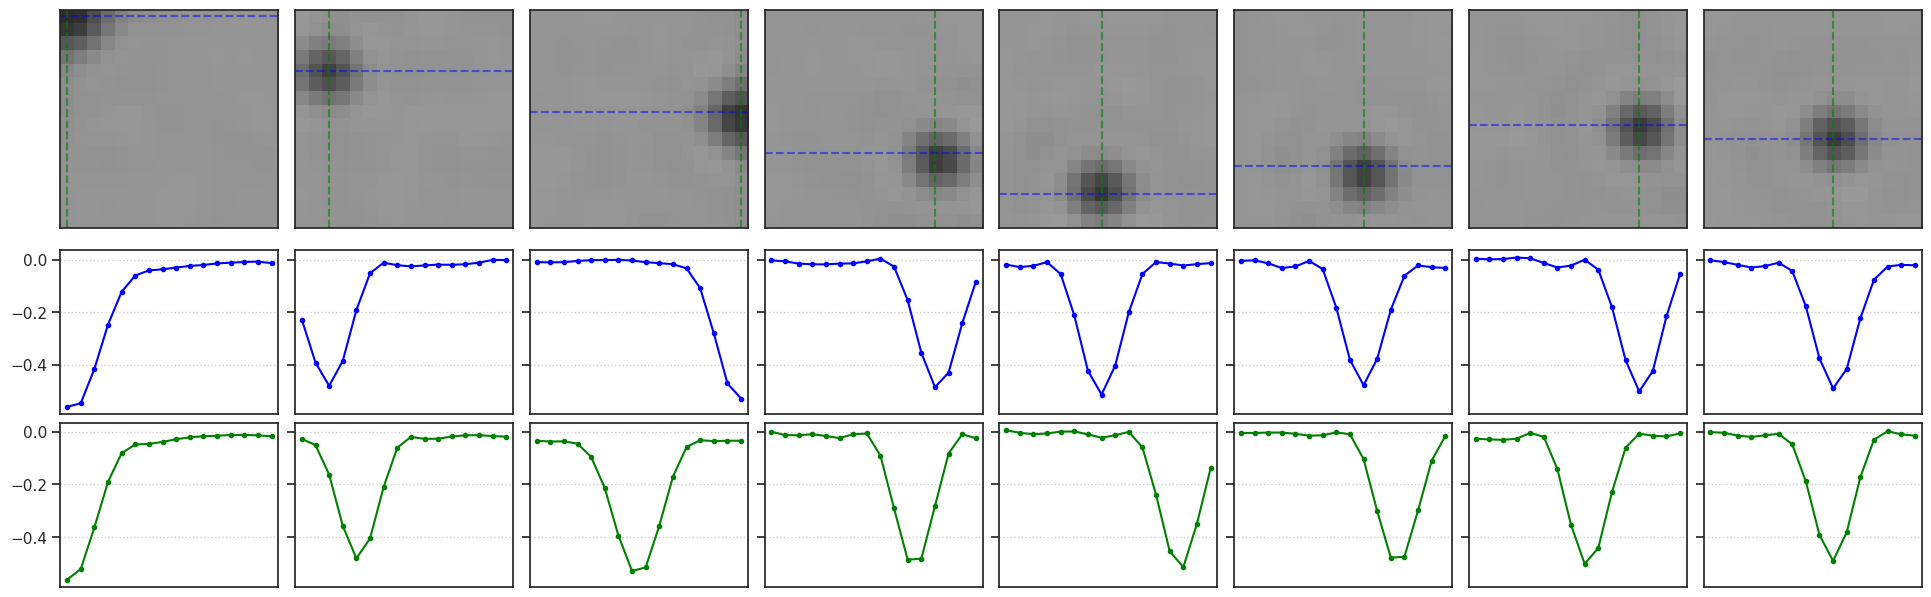

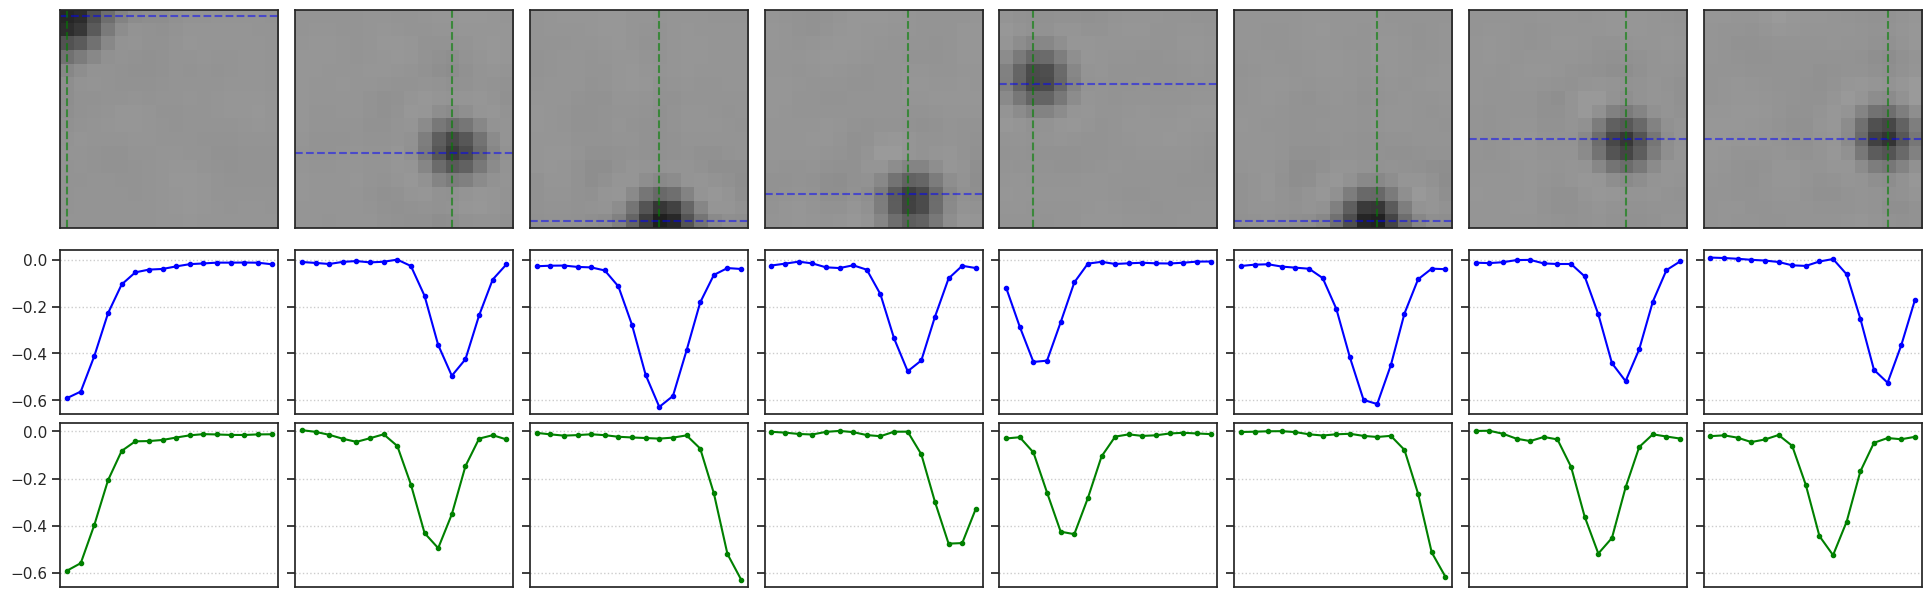

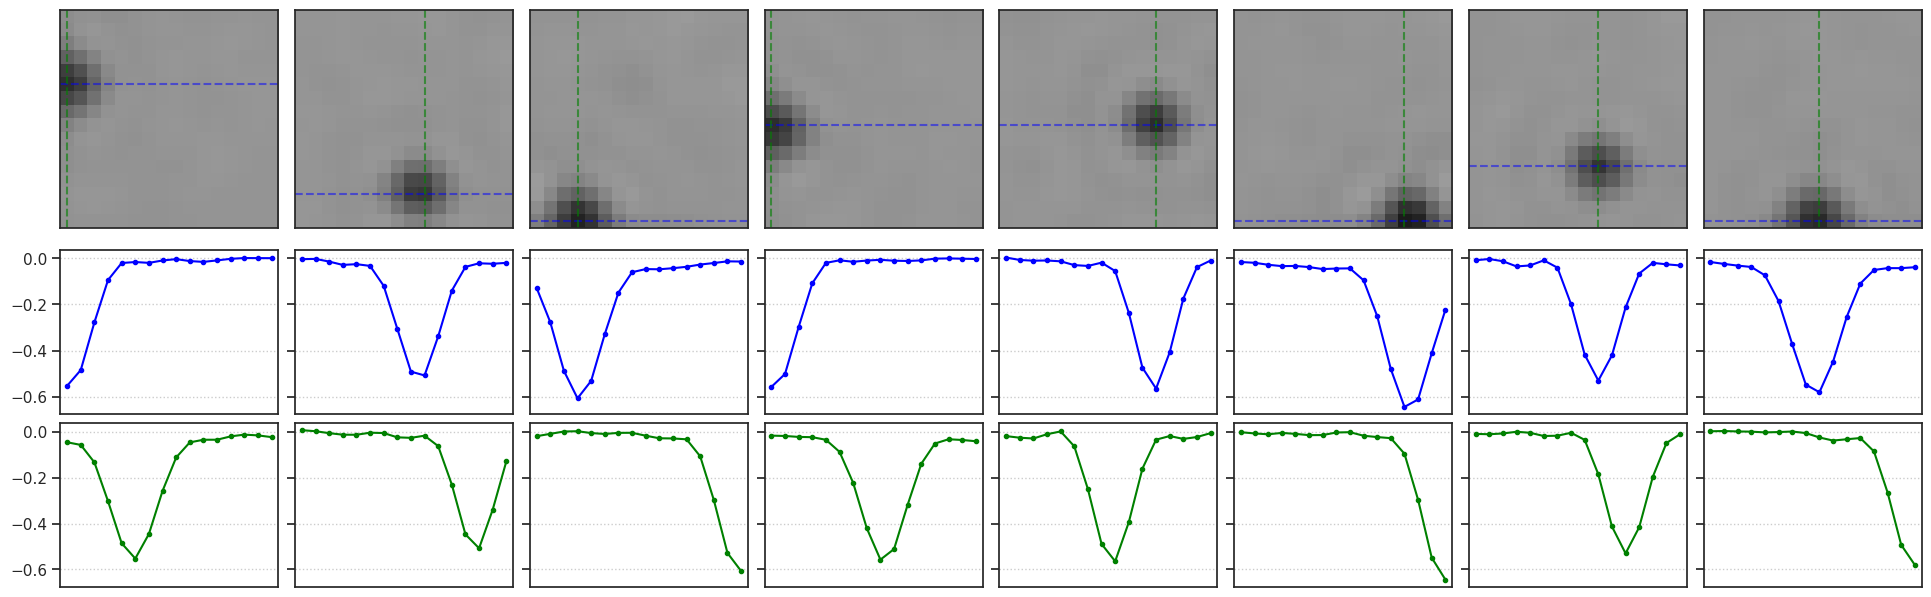

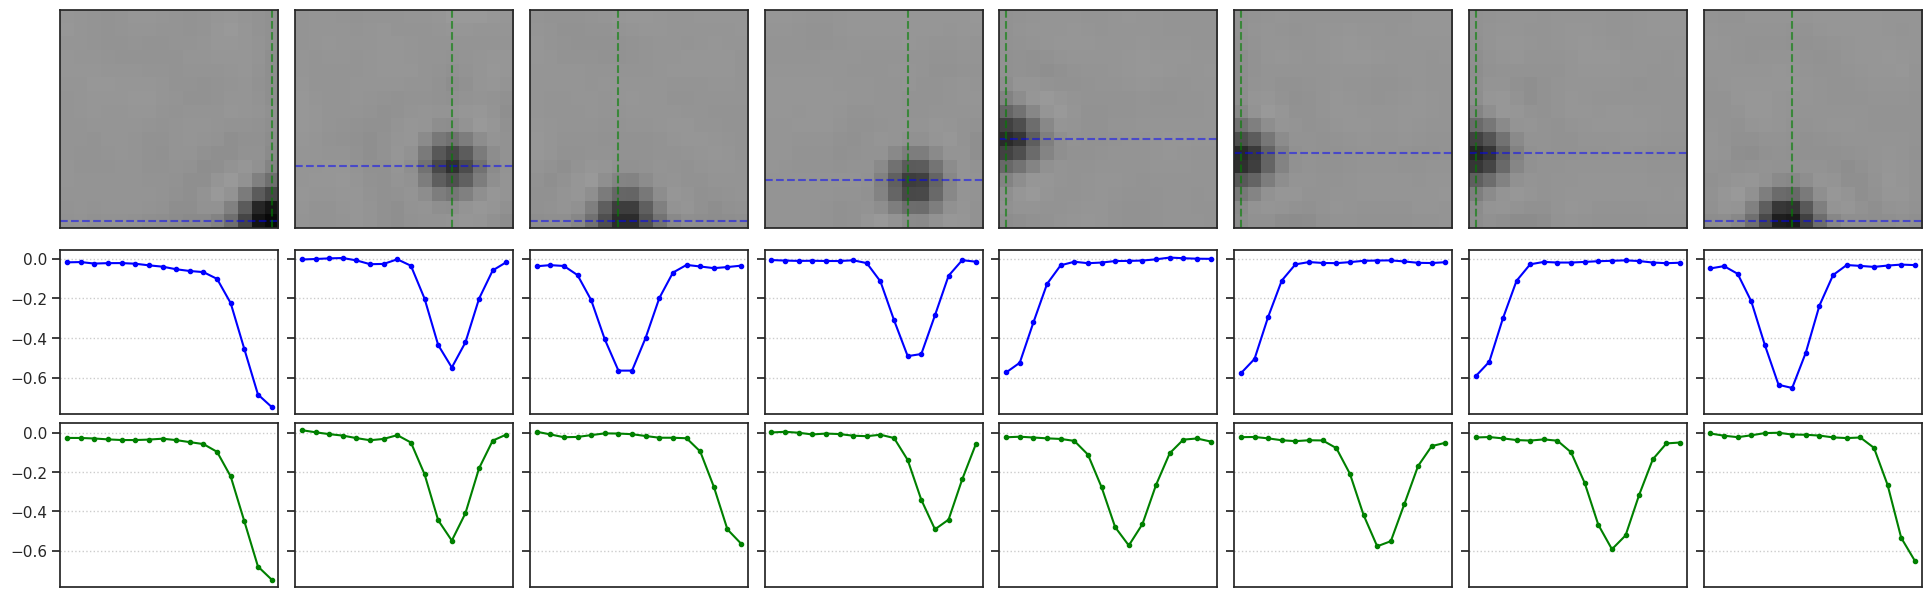

/home/hadi/Dropbox/git/jb-progress-2025/figs/igvae+sigmoid_kyoto16.pdf

In [219]:
save_file = save_fig(
    fname='igvae+sigmoid_kyoto16.pdf',
    save_dir=fig_base_dir,
    fig=fig_list,
    display=True,
)
print(save_file)

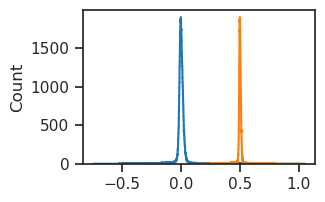

In [220]:
histplot(w.ravel())
histplot(w_rescaled.ravel());